# Music Genre Classification using Deep Learning

This notebook develops a deep learning pipeline for music genre classification using MIDI files. The workflow includes data loading, exploratory data analysis (EDA), preprocessing, feature engineering, model development, explainability using SHAP, and hyperparameter tuning.

## Import Required Libraries

Import all necessary Python libraries for data manipulation, visualization, MIDI processing, and deep learning.

In [2]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

!pip install music21
!pip install tensorflow

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from collections import Counter

# MIDI Processing
from music21 import converter, instrument, note, chord

# Deep Learning
import tensorflow as tf

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Embedding,
    LSTM,
    Dense,
    Dropout,
    Conv1D,
    MaxPooling1D,
    GlobalMaxPooling1D
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from tensorflow.keras.utils import to_categorical

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


## Define Dataset Path

Specify the location of the MIDI dataset and initialize variables required for loading metadata.

In [3]:
# ==========================================================
# Load Dataset
# ==========================================================

DATASET_PATH = "/content/drive/MyDrive/midiclassics"

selected_composers = [
    "Bach",
    "Beethoven",
    "Chopin",
    "Mozart"
]

music_data = []

for composer in selected_composers:

    composer_path = os.path.join(DATASET_PATH, composer)

    midi_files = glob.glob(os.path.join(composer_path, "*.mid"))
    midi_files += glob.glob(os.path.join(composer_path, "*.MID"))

    for file in midi_files:

        music_data.append({

            "Composer": composer,

            "Path": file

        })

music_df = pd.DataFrame(music_data)

print("Dataset Shape:", music_df.shape)

music_df.head()

Dataset Shape: (491, 2)


,Composer,Path
0,Bach,/content/drive/MyDrive/midiclassics/Bach/Bwv05...
1,Bach,/content/drive/MyDrive/midiclassics/Bach/Bwv05...
2,Bach,/content/drive/MyDrive/midiclassics/Bach/Bwv08...
3,Bach,/content/drive/MyDrive/midiclassics/Bach/Bwv08...
4,Bach,/content/drive/MyDrive/midiclassics/Bach/Bwv05...


## MIDI Parsing Utilities

Import Music21 modules used to read MIDI files and extract musical information such as notes, chords, tempo, and instruments.

In [4]:
from music21 import converter, instrument, note, chord, tempo

def extract_musical_features(file_path):

    notes = []
    chords = []
    durations = []
    offsets = []
    tempo_value = 120  # Default tempo

    try:
        midi = converter.parse(file_path)

        # Extract tempo
        for element in midi.recurse():
            if isinstance(element, tempo.MetronomeMark):
                if element.number is not None:
                    tempo_value = element.number
                    break

        # Extract notes and chords
        parts = instrument.partitionByInstrument(midi)

        if parts:
            notes_to_parse = parts.parts[0].recurse()
        else:
            notes_to_parse = midi.flatten().notes

        for element in notes_to_parse:

            if isinstance(element, note.Note):
                notes.append(str(element.pitch))
                durations.append(float(element.duration.quarterLength))
                offsets.append(float(element.offset))

            elif isinstance(element, chord.Chord):
                chord_notes = ".".join(str(n) for n in element.normalOrder)
                notes.append(chord_notes)
                chords.append(chord_notes)
                durations.append(float(element.duration.quarterLength))
                offsets.append(float(element.offset))

    except Exception:
        return {
            "Notes": [],
            "Chords": [],
            "Tempo": 120,
            "Durations": [],
            "Offsets": []
        }

    return {
        "Notes": notes,
        "Chords": chords,
        "Tempo": tempo_value,
        "Durations": durations,
        "Offsets": offsets
    }

## Preview Dataset

Display the first few records to verify that the dataset has been loaded correctly.

In [5]:
print(music_df.head())
print(music_df.shape)

  Composer                                               Path
0     Bach  /content/drive/MyDrive/midiclassics/Bach/Bwv05...
1     Bach  /content/drive/MyDrive/midiclassics/Bach/Bwv05...
2     Bach  /content/drive/MyDrive/midiclassics/Bach/Bwv08...
3     Bach  /content/drive/MyDrive/midiclassics/Bach/Bwv08...
4     Bach  /content/drive/MyDrive/midiclassics/Bach/Bwv05...
(491, 2)


# Exploratory Data Analysis (EDA)

This section explores the dataset to understand its structure, distribution, and musical characteristics before preprocessing.

In [6]:
from tqdm import tqdm

feature_data = []

for _, row in tqdm(music_df.iterrows(), total=len(music_df)):

    features = extract_musical_features(row["Path"])

    if len(features["Notes"]) < 50:
        continue

    feature_data.append({
        "Composer": row["Composer"],
        "Notes": features["Notes"],
        "Chords": features["Chords"],
        "Tempo": features["Tempo"],
        "Durations": features["Durations"],
        "Offsets": features["Offsets"],
        "Length": len(features["Notes"])
    })

processed_df = pd.DataFrame(feature_data)
print(processed_df.head())

100%|██████████| 491/491 [40:09<00:00,  4.91s/it]

  Composer                                              Notes  \
0     Bach  [2.5.9, 2.5.9, 1.4.7, 2.5.9, 4, A4, G4, F4, E4...   
1     Bach  [G3, C4, G3, C4, C4, E4, C4, G3, 7.0, 0.4, 7.0...   
2     Bach  [C4, E3, D4, D3, E4, C3, B2, F4, A2, B2, E4, C...   
3     Bach  [A4, F5, 2, C#5, D5, A4, B-4, E5, D4, F4, 7, D...   
4     Bach  [F#4, G4, A4, G4, D4, B-3, D4, A4, B-4, C5, B-...   

                                              Chords  Tempo  \
0  [2.5.9, 2.5.9, 1.4.7, 2.5.9, 4, 9.1, 0.4, 10.2...   72.0   
1  [7.0, 0.4, 7.0, 0.4, 0.4, 4.7, 0.4, 7.0, 0.4, ...   76.0   
2  [0.2, 0.2, 8.11, 6.9, 6.9, 4.8, 11.0, 11.0, 9....  200.0   
3  [2, 7, 4.7, 9.1.4, 2, 6, 4.8, 1.4.7, 11.0, 2.6...  160.0   
4  [2, 2.4, 6.7, 9.10, 0.2, 4.6, 7.9, 10.0, 9.10,...   80.0   

                                           Durations  \
0  [1.0, 0.5, 0.5, 0.5, 1.0, 0.25, 0.25, 0.25, 0....   
1  [0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.2...   
2  [0.5, 0.5, 0.5, 0.5, 0.75, 0.5, 0.5, 0.75, 0.5...   
3  [1.

## Extract Musical Statistics

Process each MIDI file to compute musical features required for exploratory analysis.

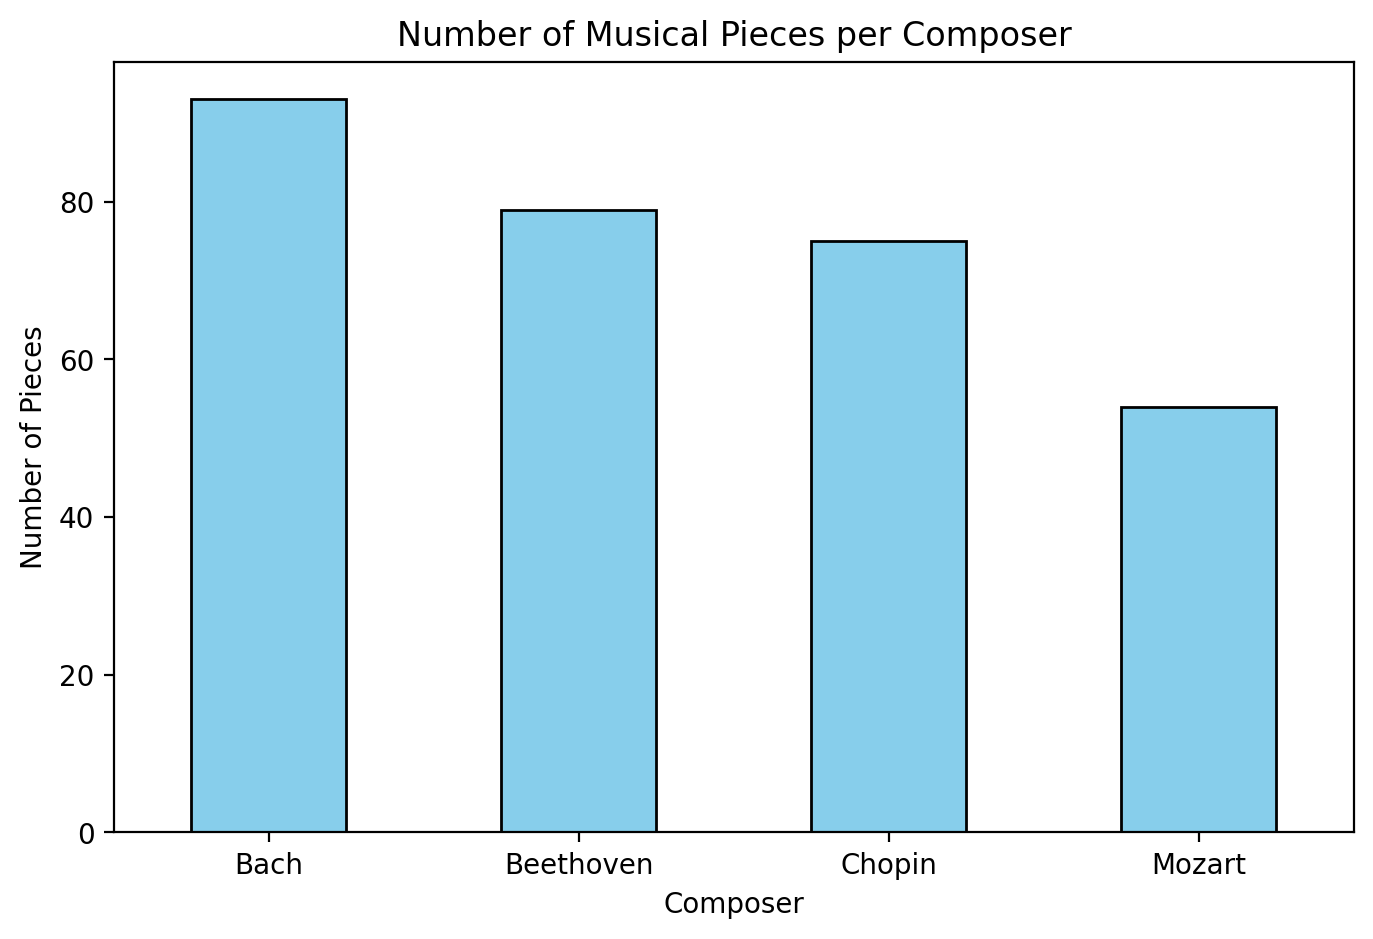

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

processed_df["Composer"].value_counts().plot(
    kind="bar",
    color="skyblue",
    edgecolor="black"
)

plt.title("Number of Musical Pieces per Composer")
plt.xlabel("Composer")
plt.ylabel("Number of Pieces")

plt.xticks(rotation=0)
plt.show()

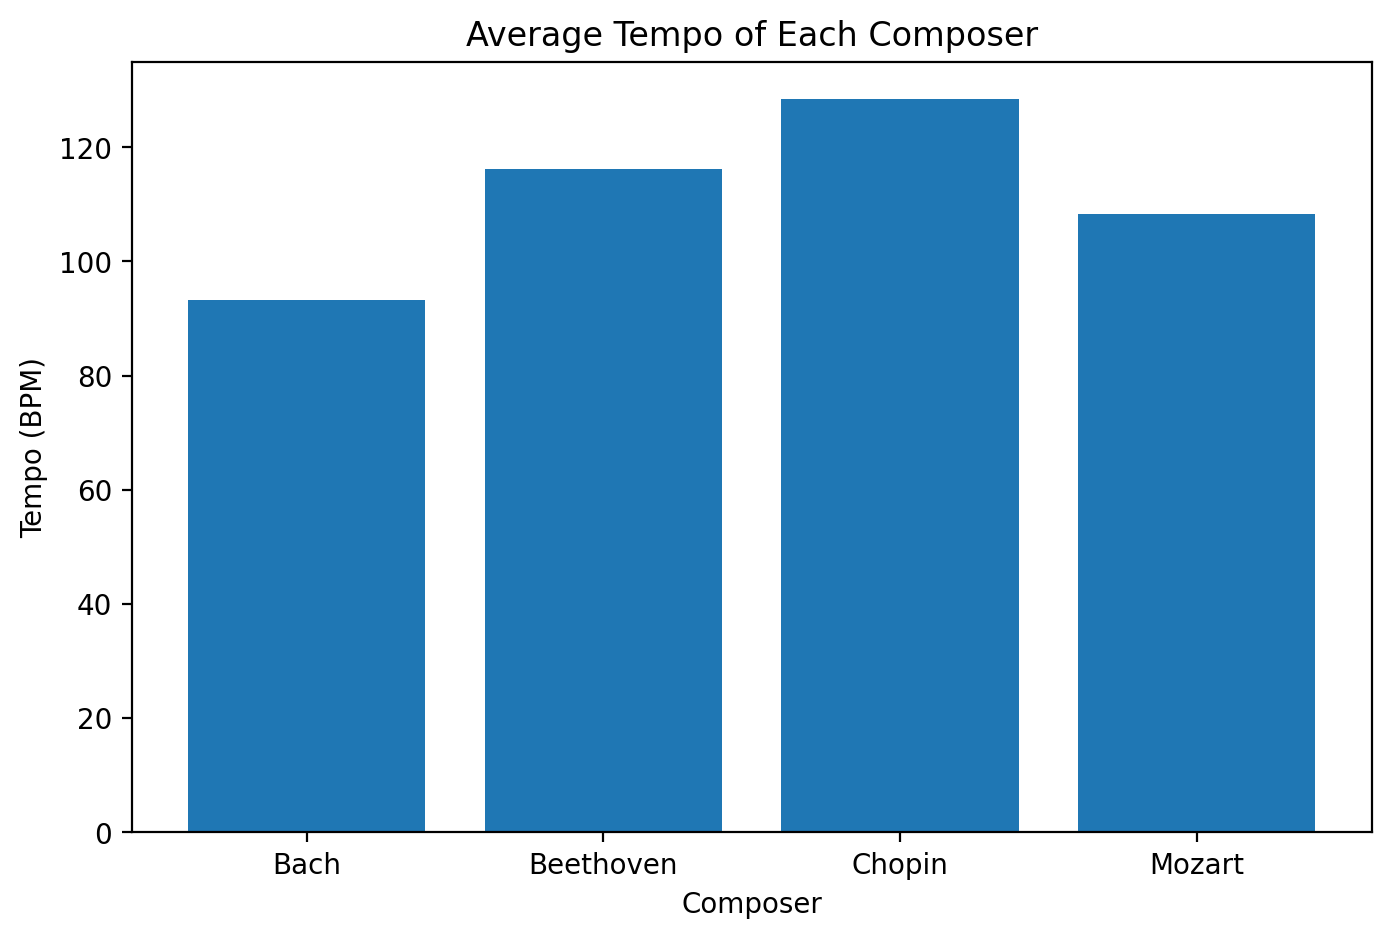

In [8]:
import matplotlib.pyplot as plt

avg_tempo = processed_df.groupby("Composer")["Tempo"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_tempo.index, avg_tempo.values)

plt.title("Average Tempo of Each Composer")
plt.xlabel("Composer")
plt.ylabel("Tempo (BPM)")

plt.show()

## Tempo Analysis

Visualize the distribution of tempo values across the dataset.

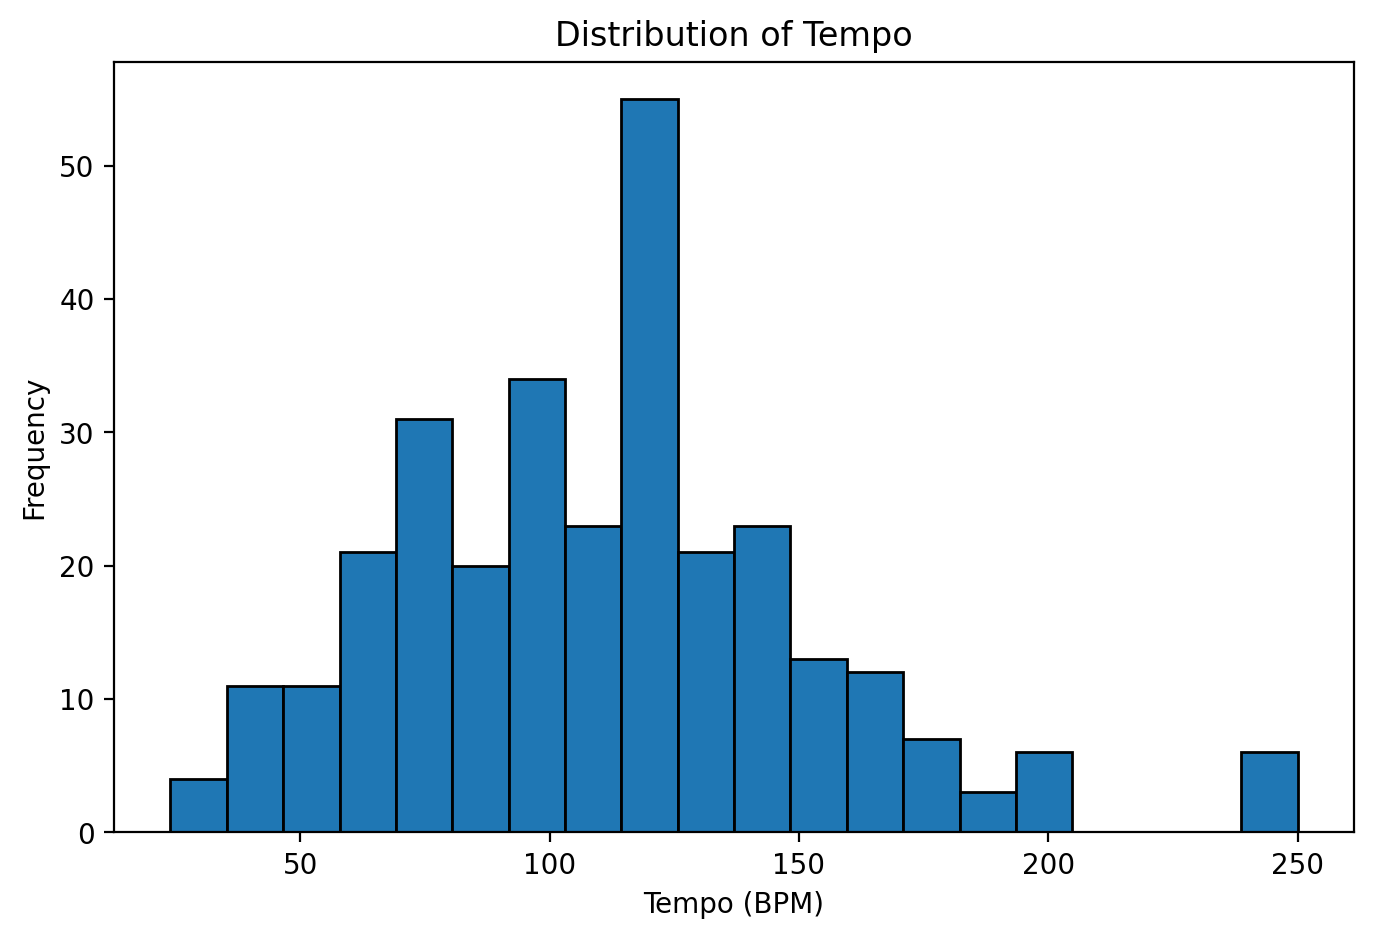

In [9]:
plt.figure(figsize=(8,5))

plt.hist(processed_df["Tempo"], bins=20, edgecolor="black")

plt.title("Distribution of Tempo")
plt.xlabel("Tempo (BPM)")
plt.ylabel("Frequency")

plt.show()

<Figure size 800x500 with 0 Axes>

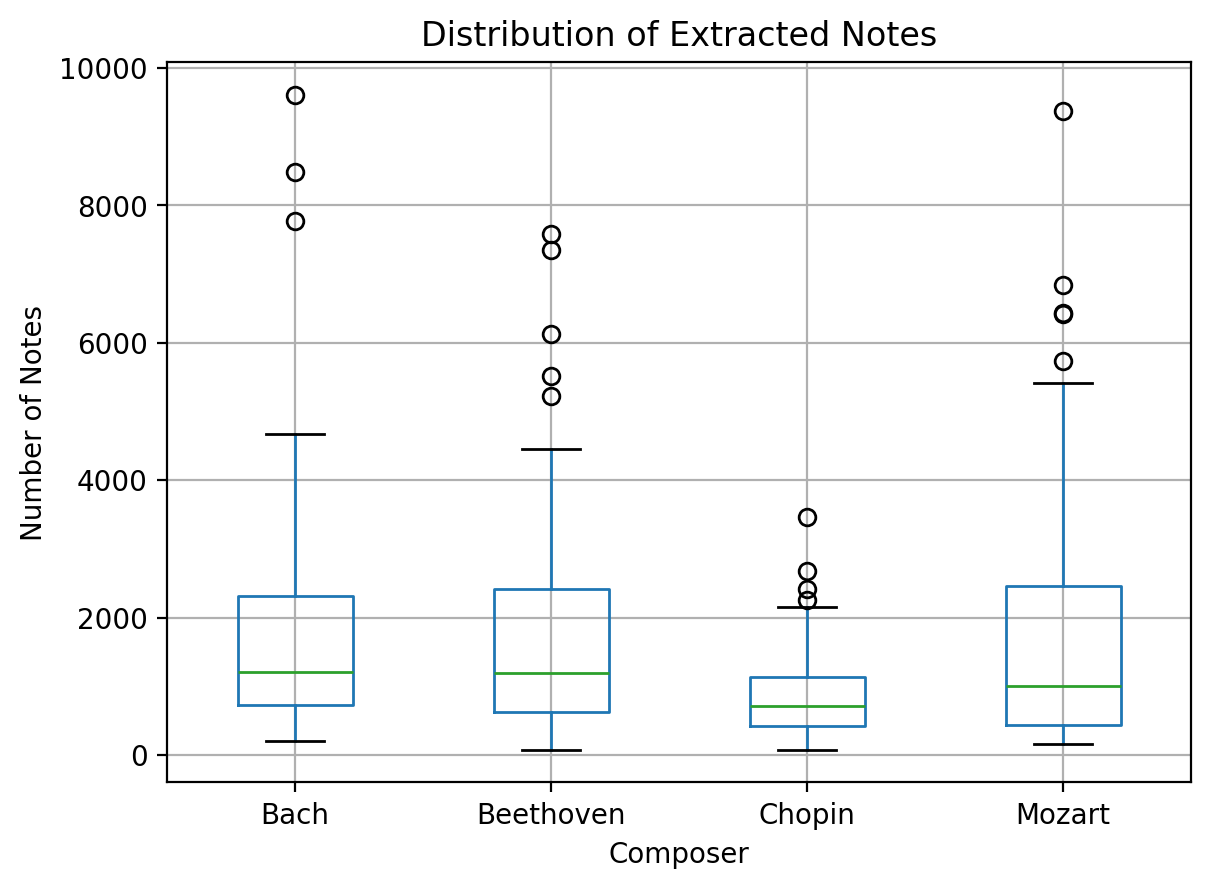

In [10]:
plt.figure(figsize=(8,5))

processed_df.boxplot(column="Length", by="Composer")

plt.title("Distribution of Extracted Notes")
plt.suptitle("")
plt.xlabel("Composer")
plt.ylabel("Number of Notes")

plt.show()

## Average Note Duration

Calculate the average note duration for each musical piece.

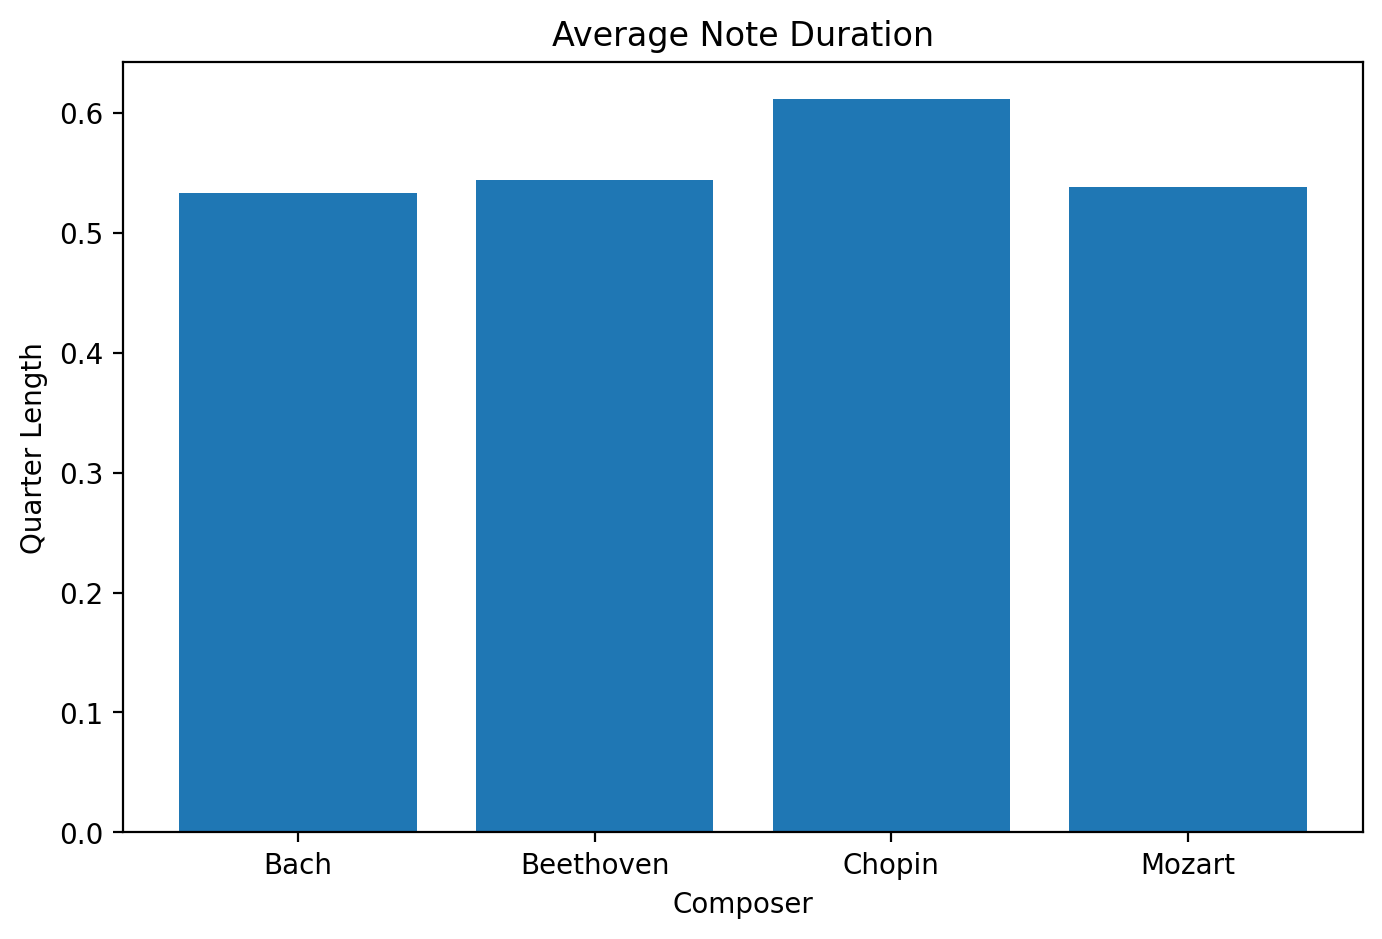

In [11]:
processed_df["Avg_Duration"] = processed_df["Durations"].apply(lambda x: sum(x)/len(x))

avg_duration = processed_df.groupby("Composer")["Avg_Duration"].mean()

plt.figure(figsize=(8,5))

plt.bar(avg_duration.index, avg_duration.values)

plt.title("Average Note Duration")
plt.xlabel("Composer")
plt.ylabel("Quarter Length")

plt.show()

In [12]:
processed_df["Avg_Duration"] = processed_df["Durations"].apply(lambda x: sum(x)/len(x))
processed_df["Avg_Offset"] = processed_df["Offsets"].apply(lambda x: sum(x)/len(x))

## Correlation Analysis

Visualize relationships among numerical musical features using a correlation heatmap.

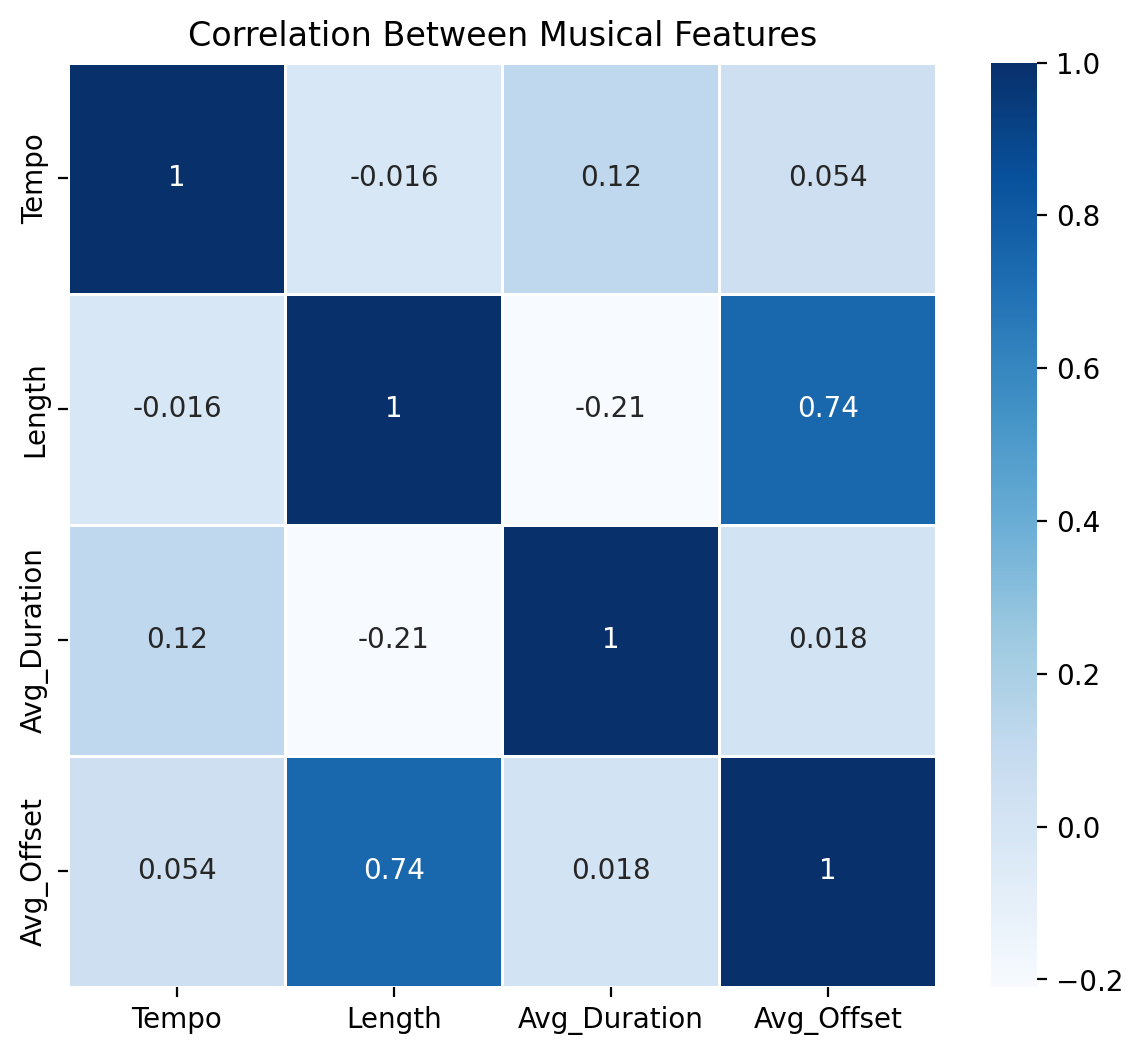

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = processed_df[["Tempo","Length","Avg_Duration","Avg_Offset"]].corr()

plt.figure(figsize=(7,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="Blues",
    linewidths=0.5
)

plt.title("Correlation Between Musical Features")

plt.show()

## Dataset Information

Inspect the dataset structure, column types, and missing values.

In [14]:
music_df.info()
music_df.isnull().sum()
music_df["Composer"].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491 entries, 0 to 490
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Composer  491 non-null    object
 1   Path      491 non-null    object
dtypes: object(2)
memory usage: 7.8+ KB


,count
Composer,
Chopin,136
Beethoven,134
Bach,131
Mozart,90


## Composer Distribution

Analyze the frequency of compositions contributed by different composers.

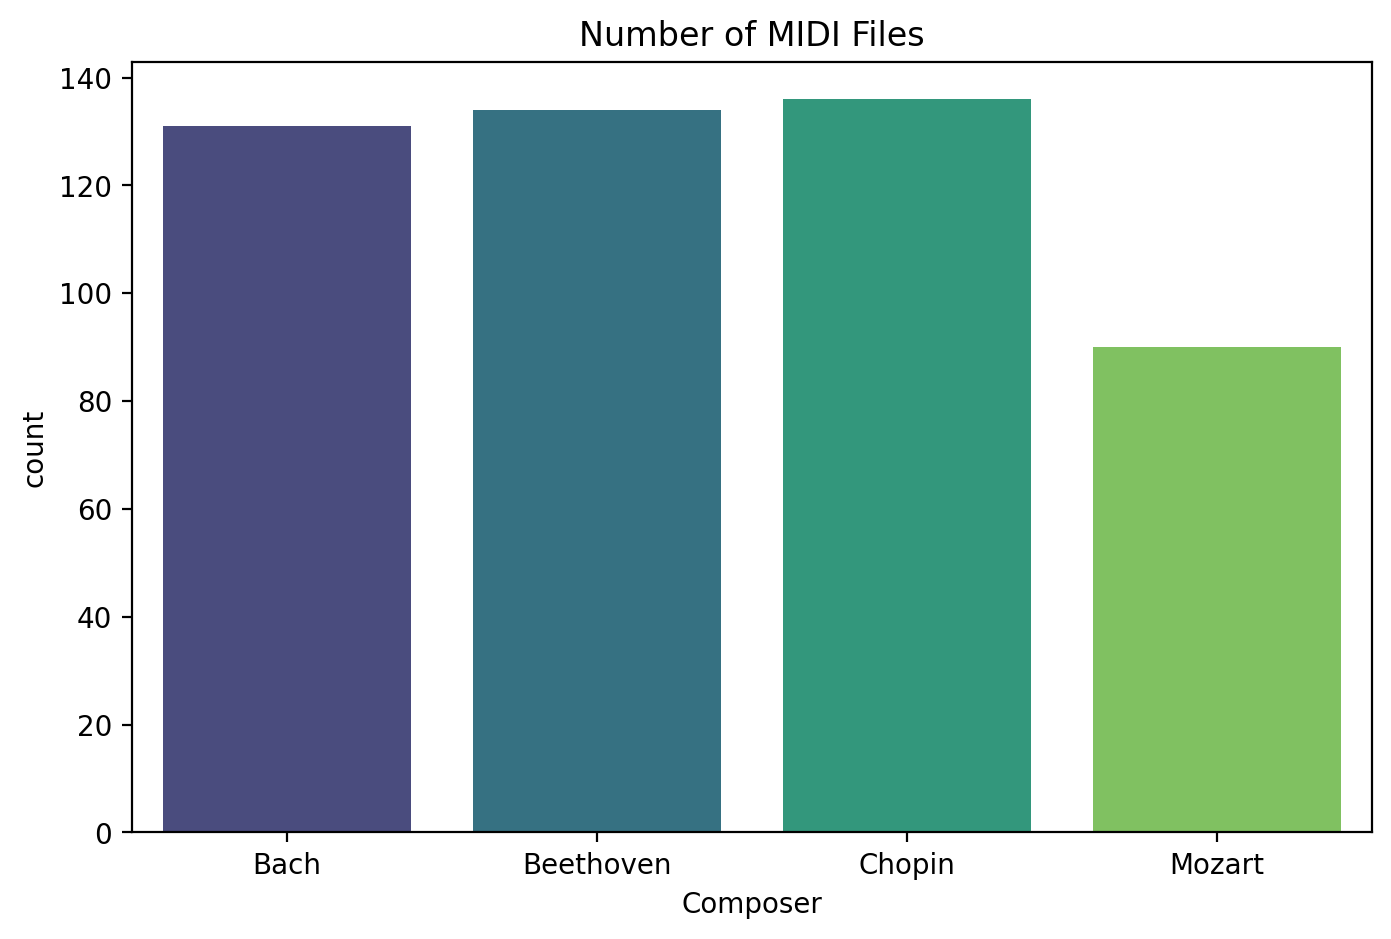

In [15]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=music_df,
    x="Composer",
    palette="viridis"
)

plt.title("Number of MIDI Files")

plt.show()

## Composer Frequency Plot

Display the number of compositions available for each composer.

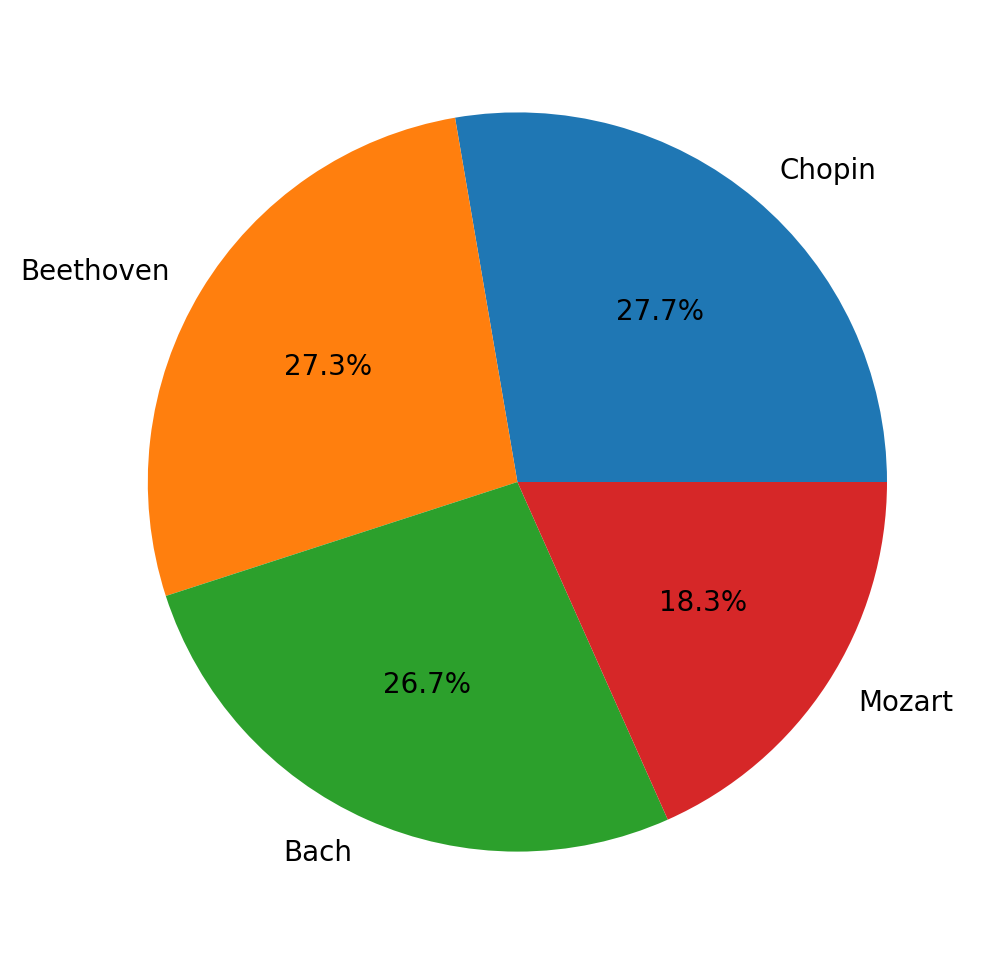

In [16]:
music_df["Composer"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%",
    figsize=(6,6)
)

plt.ylabel("")

plt.show()

In [17]:
music_df.sample(10)

,Composer,Path
372,Chopin,/content/drive/MyDrive/midiclassics/Chopin/Pre...
215,Beethoven,/content/drive/MyDrive/midiclassics/Beethoven/...
352,Chopin,/content/drive/MyDrive/midiclassics/Chopin/Gra...
331,Chopin,/content/drive/MyDrive/midiclassics/Chopin/Etu...
475,Mozart,/content/drive/MyDrive/midiclassics/Mozart/K62...
404,Mozart,/content/drive/MyDrive/midiclassics/Mozart/Con...
383,Chopin,/content/drive/MyDrive/midiclassics/Chopin/Pre...
89,Bach,/content/drive/MyDrive/midiclassics/Bach/Piano...
323,Chopin,/content/drive/MyDrive/midiclassics/Chopin/Etu...
81,Bach,/content/drive/MyDrive/midiclassics/Bach/Prelu...


## Install PrettyMIDI

Install the PrettyMIDI library for advanced MIDI analysis and visualization.

In [18]:
!pip install pretty_midi


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 6.5 MB/s eta 0:00:00


## Numerical Processing

Import NumPy for efficient numerical computations.

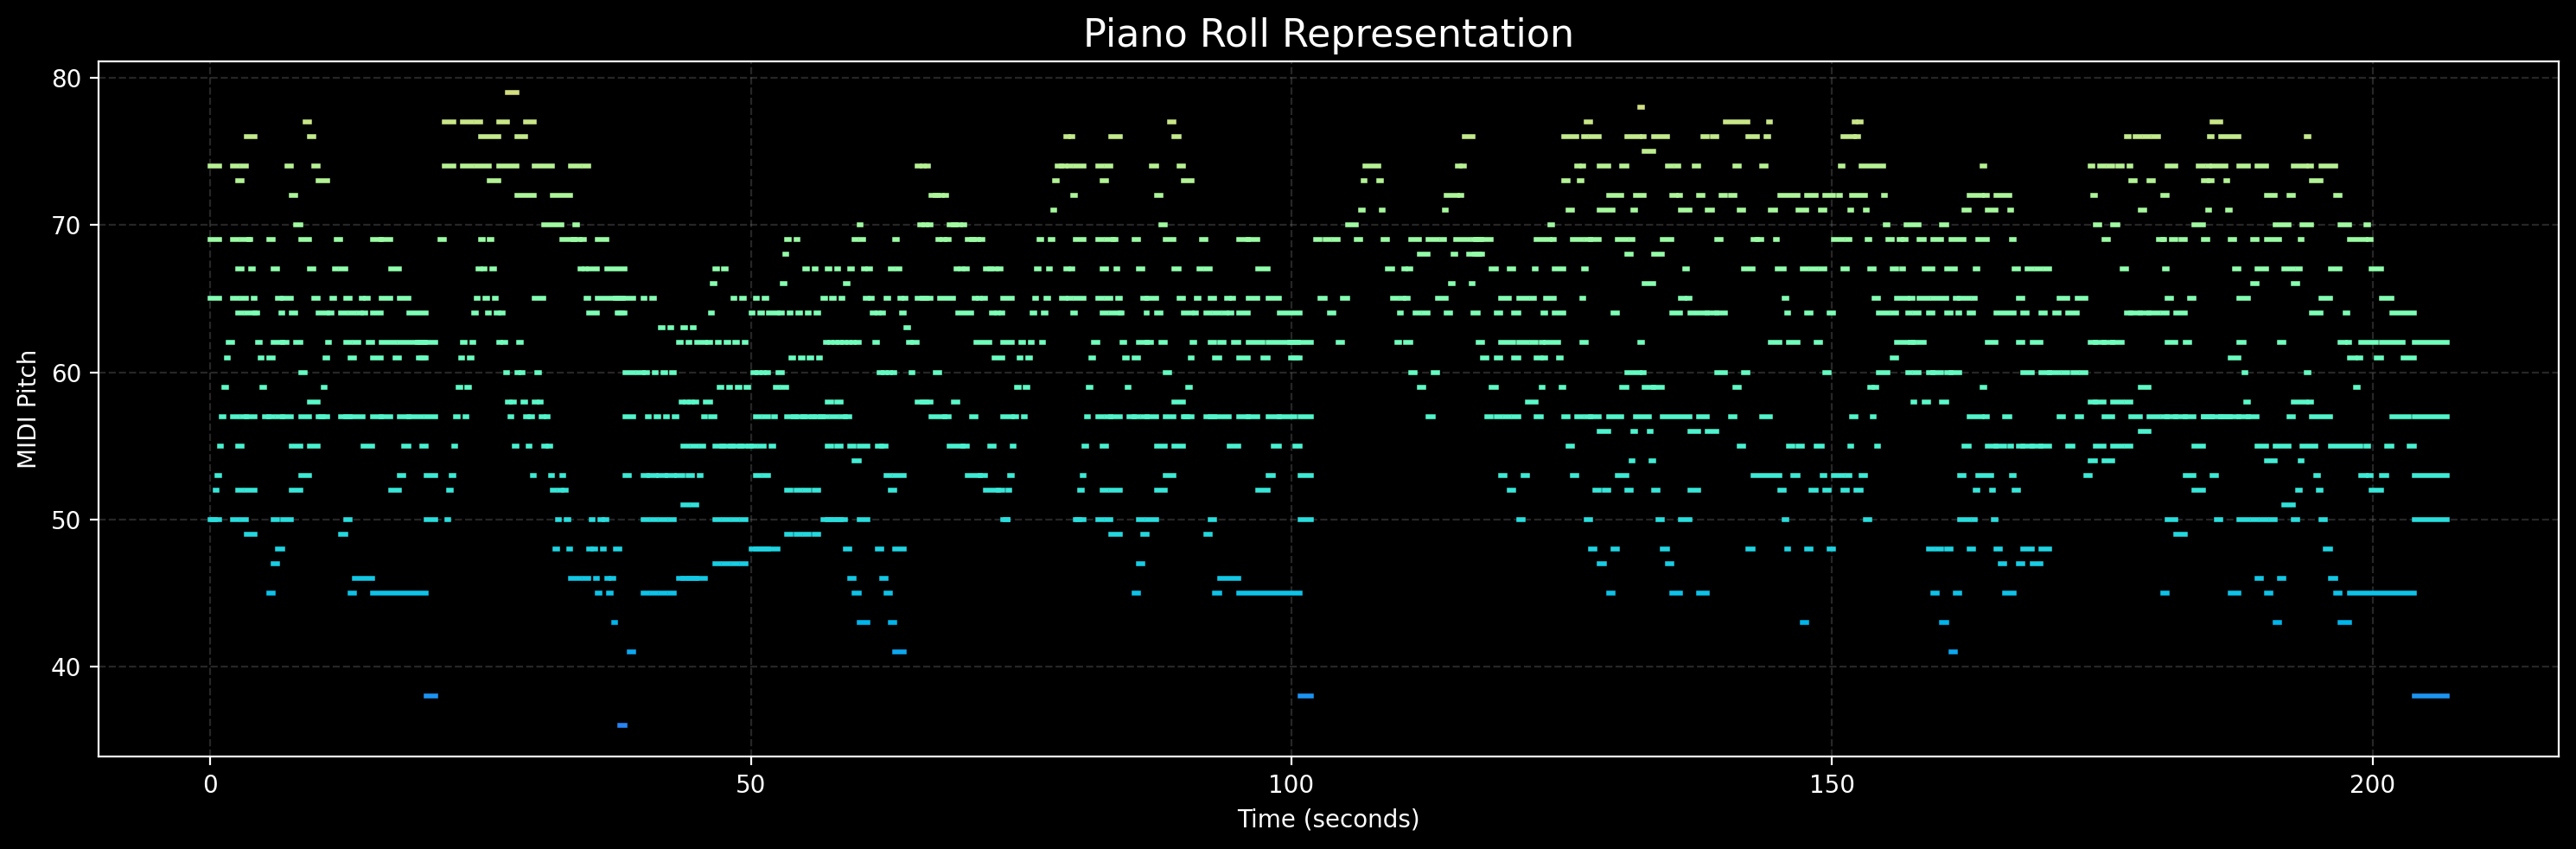

In [19]:
import pretty_midi
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors

# Load MIDI file
midi = pretty_midi.PrettyMIDI(music_df.iloc[0]["Path"])

# Create figure
fig, ax = plt.subplots(figsize=(15, 5))

# Black background
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

# Color map based on pitch
cmap = cm.rainbow
norm = colors.Normalize(vmin=21, vmax=108)

# Plot piano roll
for instrument in midi.instruments:
    if not instrument.is_drum:
        for note in instrument.notes:

            color = cmap(norm(note.pitch))

            ax.plot(
                [note.start, note.end],
                [note.pitch, note.pitch],
                linewidth=2,
                color=color
            )

# Labels and title
ax.set_title("Piano Roll Representation", fontsize=16, color="white")
ax.set_xlabel("Time (seconds)", color="white")
ax.set_ylabel("MIDI Pitch", color="white")

# White ticks
ax.tick_params(axis='x', colors='white')
ax.tick_params(axis='y', colors='white')

# White border
for spine in ax.spines.values():
    spine.set_color("white")

# Grid
ax.grid(color="gray", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()


## Visualize Note Sequence

Display a portion of the extracted musical notes to inspect the preprocessing results.

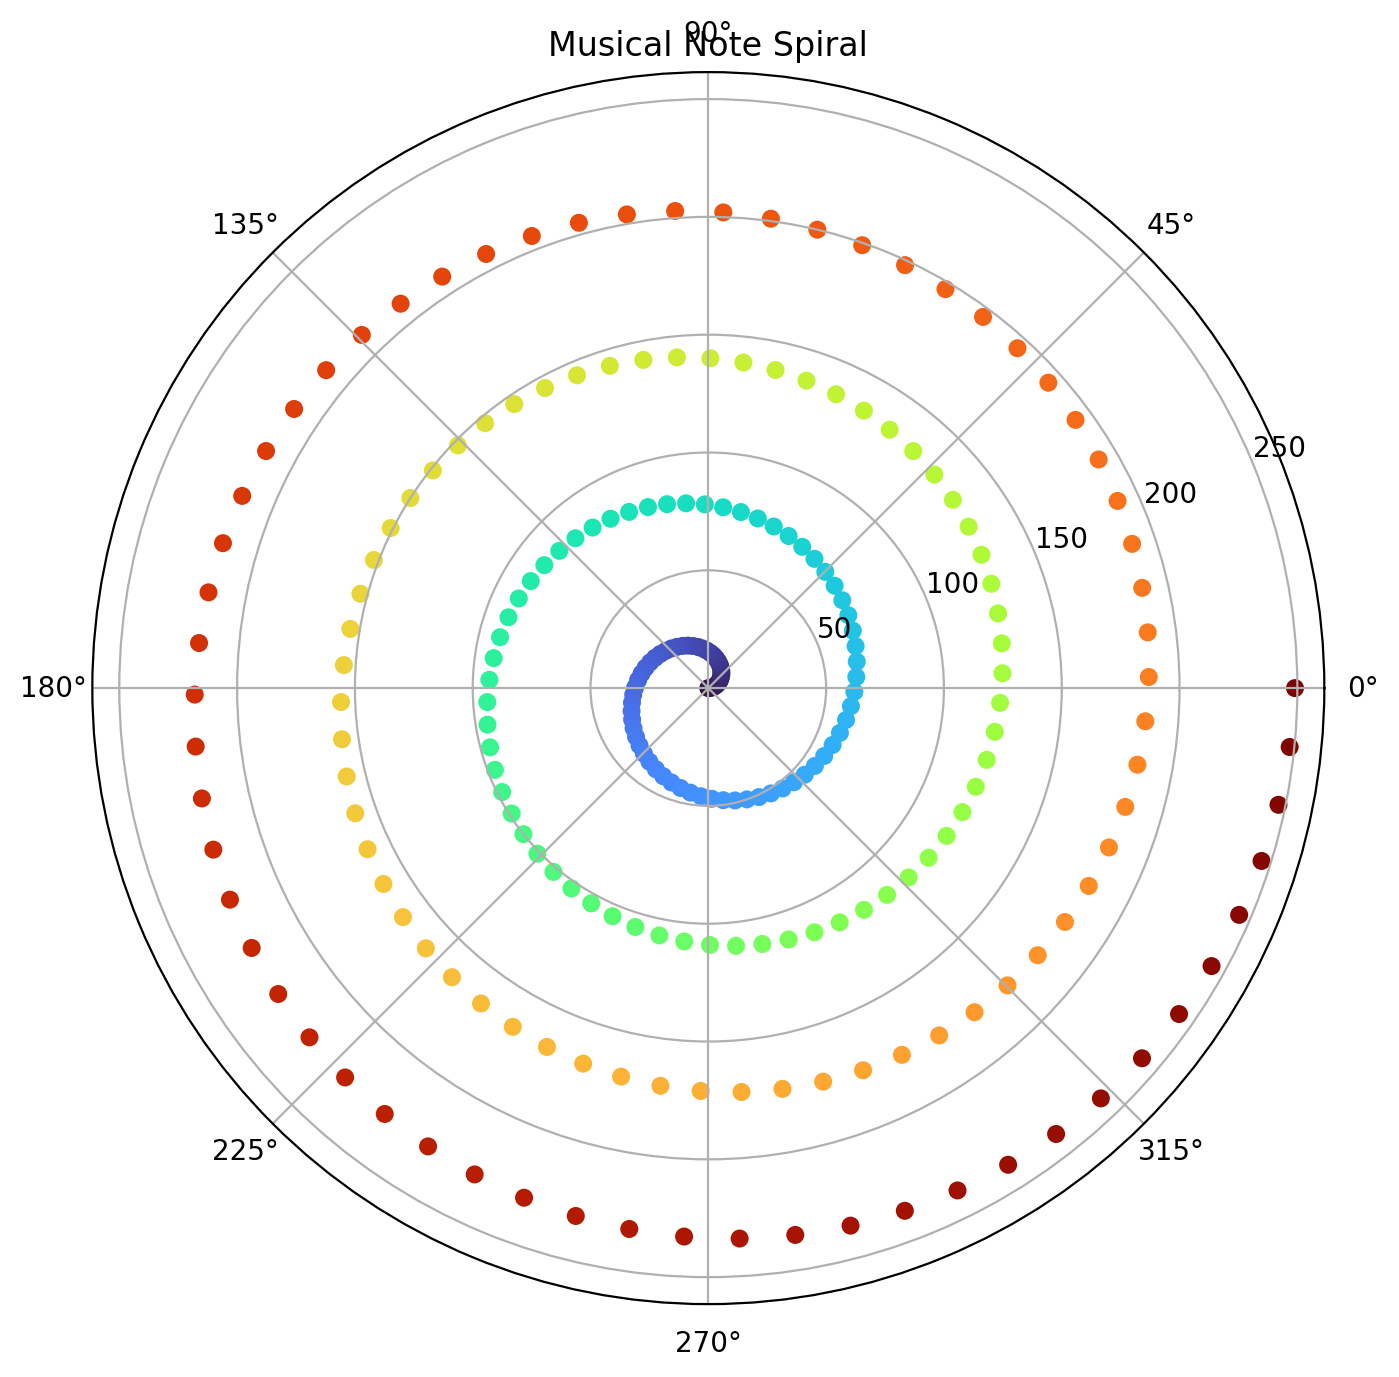

In [20]:
import numpy as np
import matplotlib.pyplot as plt

notes = processed_df.iloc[0]["Notes"][:250]

theta = np.linspace(
    0,
    8*np.pi,
    len(notes)
)

r = np.arange(len(notes))

plt.figure(figsize=(8,8))

ax = plt.subplot(111, projection="polar")

ax.scatter(
    theta,
    r,
    c=r,
    cmap="turbo",
    s=30
)

ax.set_title("Musical Note Spiral")

plt.show()

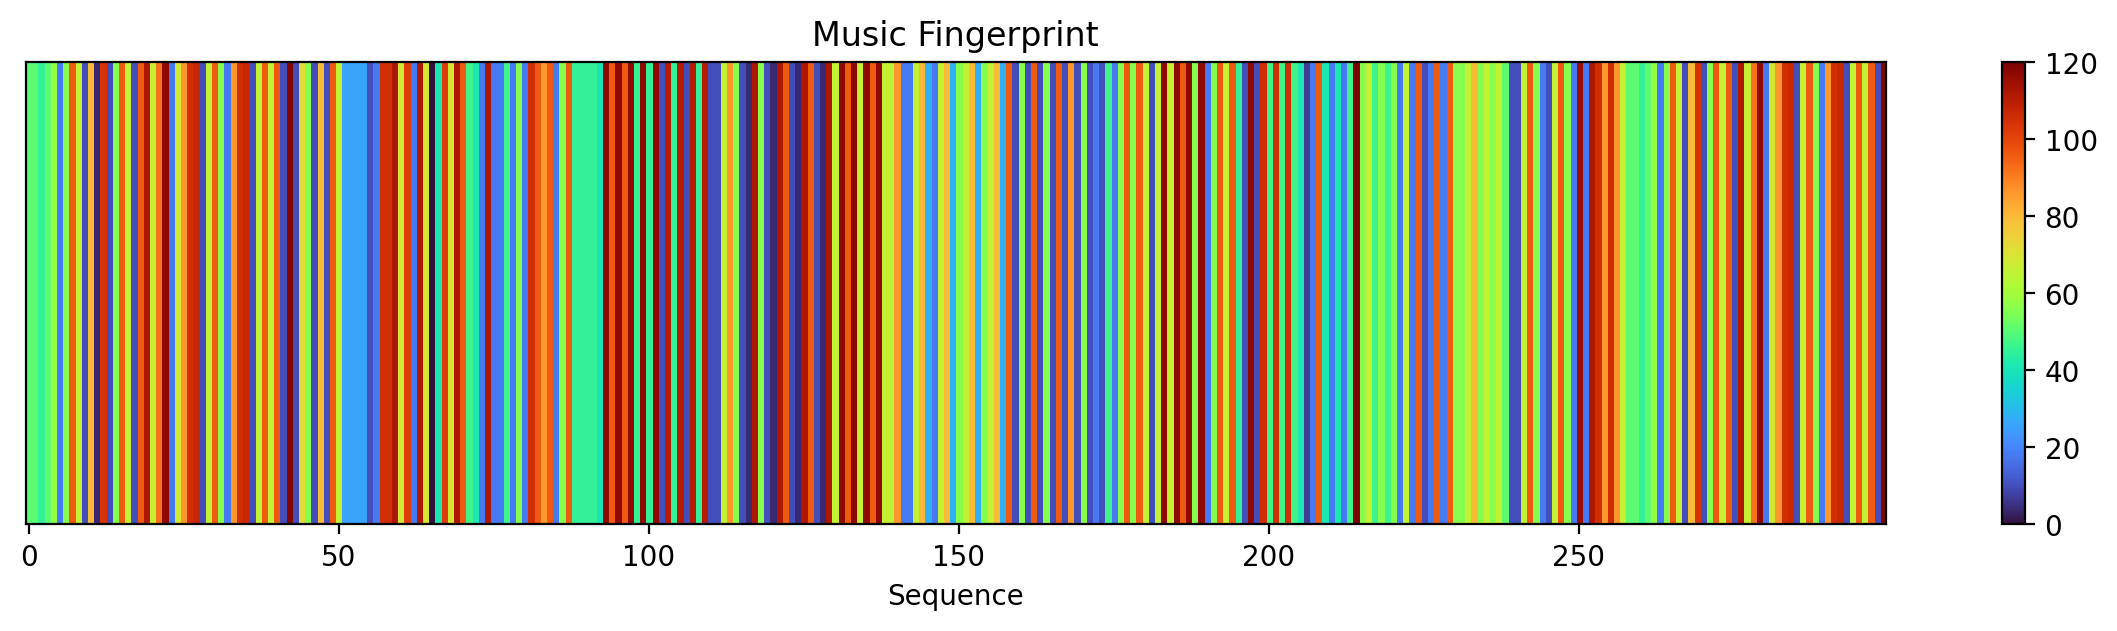

In [21]:
notes = processed_df.iloc[0]["Notes"][:300]

values = [hash(n)%128 for n in notes]

plt.figure(figsize=(15,3))

plt.imshow(
    np.array(values).reshape(1,-1),
    aspect="auto",
    cmap="turbo"
)

plt.yticks([])

plt.xlabel("Sequence")

plt.title("Music Fingerprint")

plt.colorbar()

plt.show()

# Data Preprocessing

Prepare MIDI files for deep learning by extracting notes, durations, tempos, and labels.

## Initialize Preprocessing

Prepare data structures required for processing all MIDI files.

## Process MIDI Files

Iterate through all MIDI files and extract relevant musical information.

In [22]:
# ==========================================================
# MIDI Parsing Function
# ==========================================================

from music21 import converter, instrument, note, chord

def extract_notes(file_path, max_notes=500):
    """
    Extract notes and chords from a MIDI file.

    Parameters
    ----------
    file_path : str
        Path to MIDI file.
    max_notes : int
        Maximum number of notes/chords to extract.

    Returns
    -------
    list
        List of note/chord tokens.
    """

    notes = []

    try:

        midi = converter.parse(file_path)

        parts = instrument.partitionByInstrument(midi)

        if parts:
            notes_to_parse = parts.parts[0].recurse()
        else:
            notes_to_parse = midi.flatten().notes

        for element in notes_to_parse:

            if isinstance(element, note.Note):
                notes.append(str(element.pitch))

            elif isinstance(element, chord.Chord):
                notes.append(".".join(str(n) for n in element.normalOrder))

            if len(notes) >= max_notes:
                break

    except Exception:
        return []

    return notes

In [23]:
# ==========================================================
# Process Dataset
# ==========================================================

processed_data = []
failed_files = []

for _, row in tqdm(music_df.iterrows(),
                   total=len(music_df),
                   desc="Processing MIDI Files"):

    notes = extract_notes(row["Path"])

    if len(notes) < 50:
        failed_files.append(row["Path"])
        continue

    processed_data.append({
        "Composer": row["Composer"],
        "Notes": notes
    })

Processing MIDI Files: 100%|██████████| 491/491 [07:52<00:00,  1.04it/s]


## Create Processed Dataset

Convert the extracted musical features into a structured DataFrame.

In [24]:
processed_df = pd.DataFrame(processed_data)

print("Processed Dataset Shape:", processed_df.shape)

processed_df.head()

Processed Dataset Shape: (301, 2)


,Composer,Notes
0,Bach,"[2.5.9, 2.5.9, 1.4.7, 2.5.9, 4, A4, G4, F4, E4..."
1,Bach,"[G3, C4, G3, C4, C4, E4, C4, G3, 7.0, 0.4, 7.0..."
2,Bach,"[C4, E3, D4, D3, E4, C3, B2, F4, A2, B2, E4, C..."
3,Bach,"[A4, F5, 2, C#5, D5, A4, B-4, E5, D4, F4, 7, D..."
4,Bach,"[F#4, G4, A4, G4, D4, B-3, D4, A4, B-4, C5, B-..."


## Failed File Summary

Display the number of files that could not be processed successfully.

In [25]:
print("Failed Files:", len(failed_files))

Failed Files: 190


## Sequence Length Calculation

Compute the length of each musical note sequence.

In [26]:
processed_df["Length"] = processed_df["Notes"].apply(len)

processed_df.head()

,Composer,Notes,Length
0,Bach,"[2.5.9, 2.5.9, 1.4.7, 2.5.9, 4, A4, G4, F4, E4...",500
1,Bach,"[G3, C4, G3, C4, C4, E4, C4, G3, 7.0, 0.4, 7.0...",500
2,Bach,"[C4, E3, D4, D3, E4, C3, B2, F4, A2, B2, E4, C...",500
3,Bach,"[A4, F5, 2, C#5, D5, A4, B-4, E5, D4, F4, 7, D...",500
4,Bach,"[F#4, G4, A4, G4, D4, B-3, D4, A4, B-4, C5, B-...",500


In [27]:
processed_df["Length"].describe()

,Length
count,301.000000
mean,457.142857
std,97.533667
min,80.000000
25%,500.000000
50%,500.000000
75%,500.000000
max,500.000000


## Sequence Statistics

Summarize note sequence lengths using descriptive statistics.

## Sequence Length Distribution

Visualize the distribution of sequence lengths across the dataset.

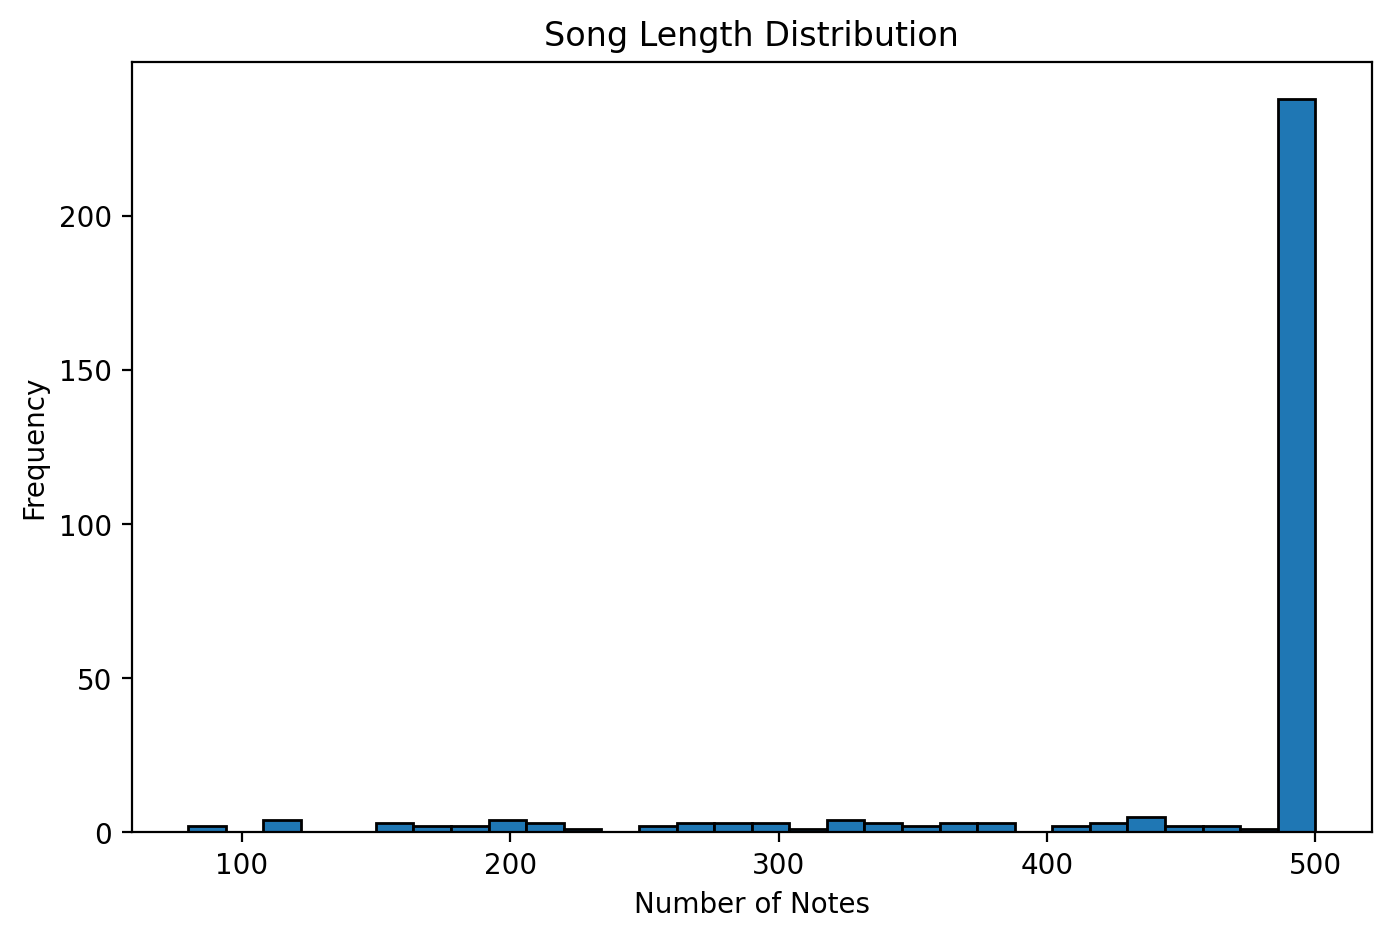

In [28]:
plt.figure(figsize=(8,5))

plt.hist(processed_df["Length"],
         bins=30,
         edgecolor="black")

plt.title("Song Length Distribution")
plt.xlabel("Number of Notes")
plt.ylabel("Frequency")

plt.show()

## Average Sequence Length by Composer

Compare average note sequence lengths for different composers.

In [29]:
processed_df.groupby("Composer")["Length"].mean()

,Length
Composer,
Bach,488.462366
Beethoven,441.556962
Chopin,440.573333
Mozart,449.018519


## Composer-wise Sequence Visualization

Visualize differences in sequence lengths among composers.

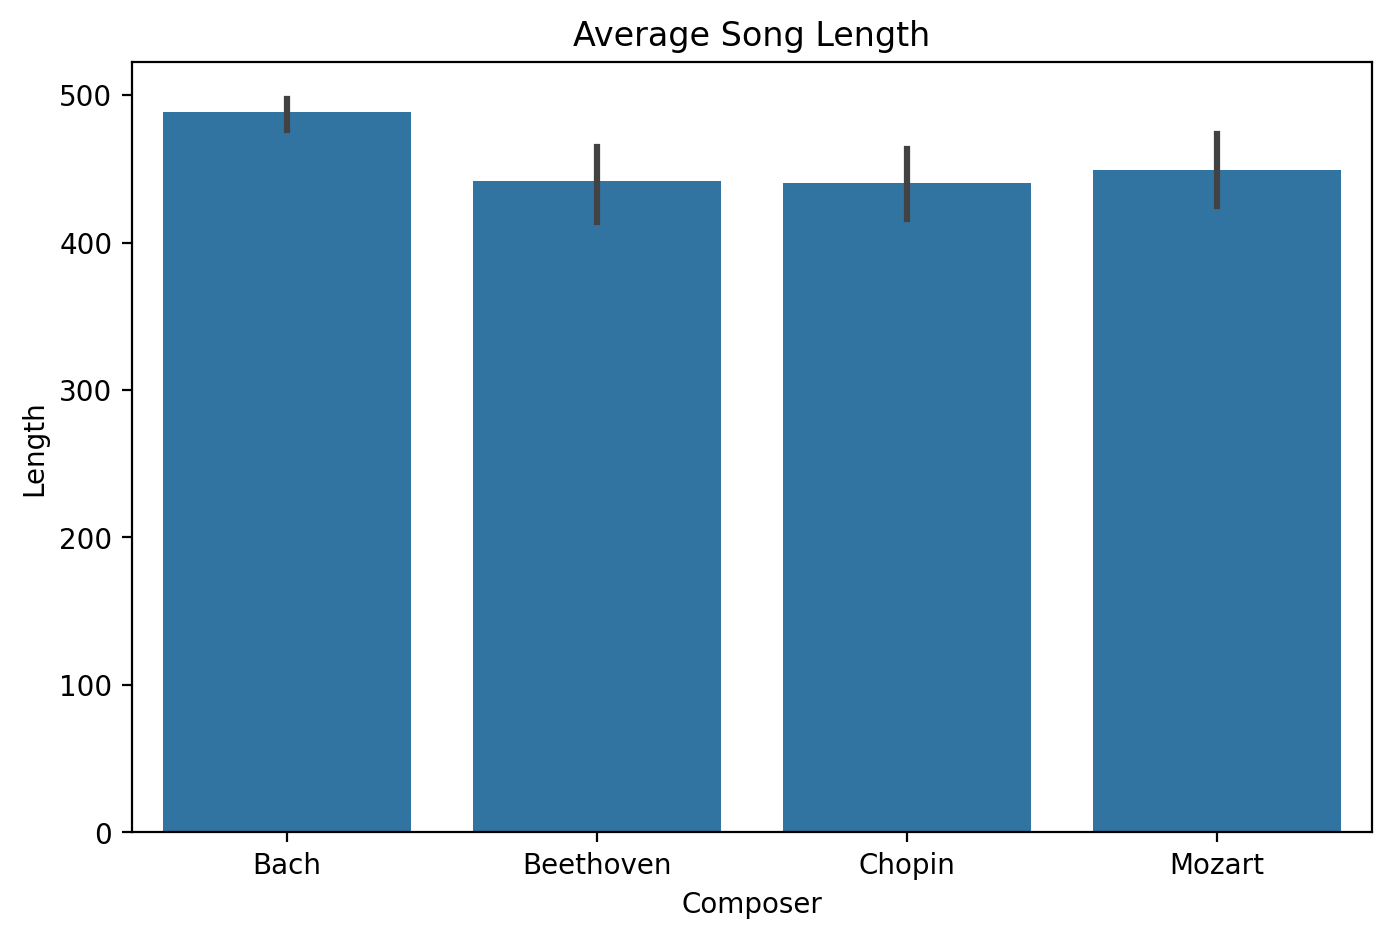

In [30]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=processed_df,
    x="Composer",
    y="Length",
    estimator=np.mean
)

plt.title("Average Song Length")

plt.show()

## Save Processed Dataset

Store the processed dataset for future use.

In [31]:
processed_df.to_pickle("processed_music.pkl")

print("Preprocessed data saved successfully.")

Preprocessed data saved successfully.


## Reload Processed Dataset

Load the saved processed dataset to continue experimentation.

In [32]:
processed_df = pd.read_pickle("processed_music.pkl")

# Feature Engineering

Transform symbolic musical information into numerical representations suitable for deep learning models.

## Create Note Vocabulary

Identify all unique musical notes present in the dataset.

In [33]:
# ==========================================================
# Build Vocabulary
# ==========================================================

all_notes = []

for notes in processed_df["Notes"]:
    all_notes.extend(notes)

print("Total Notes:", len(all_notes))

unique_notes = sorted(set(all_notes))

print("Unique Notes:", len(unique_notes))

Total Notes: 137600
Unique Notes: 682


## Build Note Mapping

Assign a unique integer to every musical note.

In [34]:
# ==========================================================
# Create Dictionary
# ==========================================================

note_to_int = {
    note: number
    for number, note in enumerate(unique_notes)
}

int_to_note = {
    number: note
    for number, note in enumerate(unique_notes)
}

print("Vocabulary Size:", len(note_to_int))

Vocabulary Size: 682


## Encode Musical Notes

Convert symbolic note sequences into integer sequences.

In [35]:
for i, (k, v) in enumerate(note_to_int.items()):

    print(k, "->", v)

    if i == 10:
        break

0 -> 0
0.1 -> 1
0.1.2 -> 2
0.1.2.3 -> 3
0.1.3 -> 4
0.1.3.5 -> 5
0.1.3.5.8 -> 6
0.1.3.6.8 -> 7
0.1.3.7 -> 8
0.1.4 -> 9
0.1.4.5 -> 10


In [36]:
# ==========================================================
# Convert Notes into Integers
# ==========================================================

processed_df["Encoded"] = processed_df["Notes"].apply(

    lambda song: [note_to_int[n] for n in song]

)

processed_df.head()

,Composer,Notes,Length,Encoded
0,Bach,"[2.5.9, 2.5.9, 1.4.7, 2.5.9, 4, A4, G4, F4, E4...",500,"[247, 247, 92, 247, 305, 611, 679, 666, 654, 6..."
1,Bach,"[G3, C4, G3, C4, C4, E4, C4, G3, 7.0, 0.4, 7.0...",500,"[678, 634, 678, 634, 634, 654, 634, 678, 455, ..."
2,Bach,"[C4, E3, D4, D3, E4, C3, B2, F4, A2, B2, E4, C...",500,"[634, 653, 641, 640, 654, 633, 621, 666, 609, ..."
3,Bach,"[A4, F5, 2, C#5, D5, A4, B-4, E5, D4, F4, 7, D...",500,"[611, 667, 199, 630, 642, 611, 617, 655, 641, ..."
4,Bach,"[F#4, G4, A4, G4, D4, B-3, D4, A4, B-4, C5, B-...",500,"[660, 679, 611, 679, 641, 616, 641, 611, 617, ..."


In [37]:
print("Original")

print(processed_df["Notes"][0][:20])

print()

print("Encoded")

print(processed_df["Encoded"][0][:20])

Original
['2.5.9', '2.5.9', '1.4.7', '2.5.9', '4', 'A4', 'G4', 'F4', 'E4', 'D4', 'C#4', 'B3', '9.1', 'D4', 'G4', 'F4', 'E4', 'D4', 'F4', 'D5']

Encoded
[247, 247, 92, 247, 305, 611, 679, 666, 654, 641, 629, 622, 569, 641, 679, 666, 654, 641, 666, 642]


## Prepare Encoded Features

Generate numerical features for model training.

In [38]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

processed_df["Label"] = label_encoder.fit_transform(
    processed_df["Composer"]
)

print(label_encoder.classes_)

['Bach' 'Beethoven' 'Chopin' 'Mozart']


## Verify Encoding

Compare original note sequences with encoded representations.

In [39]:
mapping = pd.DataFrame({

    "Composer": label_encoder.classes_,

    "Label": range(len(label_encoder.classes_))

})

mapping

,Composer,Label
0,Bach,0
1,Beethoven,1
2,Chopin,2
3,Mozart,3


In [40]:
from tensorflow.keras.utils import to_categorical

y = to_categorical(processed_df["Label"])

print(y.shape)

(301, 4)


## Save Encoders

Store encoding objects for future inference.

In [41]:
import pickle

with open("note_to_int.pkl","wb") as f:
    pickle.dump(note_to_int,f)

with open("label_encoder.pkl","wb") as f:
    pickle.dump(label_encoder,f)

# Data Preparation

Prepare the feature matrix and labels for training, validation, and testing.

## Pad Sequences

Ensure all note sequences have equal length.

In [42]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LENGTH = 500

X = pad_sequences(
    processed_df["Encoded"],
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print(X.shape)

(301, 500)


## Prepare Labels

Extract target labels for supervised learning.

In [43]:
y = processed_df["Label"].values

print(y.shape)

(301,)


## Split Dataset

Divide the dataset into training and validation sets.

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

In [45]:
X_train, X_val, y_train, y_val = train_test_split(

    X_train,
    y_train,

    test_size=0.20,

    random_state=42,

    stratify=y_train

)

## Verify Dataset Shapes

Display the dimensions of training and validation datasets.

In [46]:
print("Training :", X_train.shape)

print("Validation :", X_val.shape)

print("Testing :", X_test.shape)

Training : (192, 500)
Validation : (48, 500)
Testing : (61, 500)


# Building LSTM Model

Construct, train, and evaluate an LSTM network for music genre classification.

In [47]:
# ==========================================================
# SPLIT THE SONGS (NOT THE SEQUENCES)
# ==========================================================

from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    processed_df,
    test_size=0.20,
    random_state=42,
    stratify=processed_df["Label"]
)

train_df, val_df = train_test_split(
    train_df,
    test_size=0.20,
    random_state=42,
    stratify=train_df["Label"]
)

print("Training Songs   :", len(train_df))
print("Validation Songs :", len(val_df))
print("Testing Songs    :", len(test_df))

Training Songs   : 192
Validation Songs : 48
Testing Songs    : 61


In [48]:
# ==========================================================
# CREATE SEQUENCES
# ==========================================================

import numpy as np

SEQUENCE_LENGTH = 100
STEP = 1

def create_sequences(df):

    X = []
    y = []

    for _, row in df.iterrows():

        encoded = row["Encoded"]

        label = row["Label"]

        if len(encoded) <= SEQUENCE_LENGTH:
            continue

        for i in range(0, len(encoded) - SEQUENCE_LENGTH, STEP):

            X.append(
                encoded[i:i+SEQUENCE_LENGTH]
            )

            y.append(label)

    return np.array(X), np.array(y)

In [49]:
# ==========================================================
# GENERATE DATASETS
# ==========================================================

X_train, y_train = create_sequences(train_df)

X_val, y_val = create_sequences(val_df)

X_test, y_test = create_sequences(test_df)

print(X_train.shape)
print(X_val.shape)
print(X_test.shape)

print(y_train.shape)
print(y_val.shape)
print(y_test.shape)

(68237, 100)
(17655, 100)
(21646, 100)
(68237,)
(17655,)
(21646,)


## LSTM Model Architecture

Define the LSTM architecture, compile the model, train it, evaluate its performance, and save the best-performing model.

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Input

vocab_size = len(note_to_int)

lstm_model = Sequential([

    Input(shape=(100,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    LSTM(
        128,
        return_sequences=True
    ),

    Dropout(0.3),

    LSTM(64),

    Dropout(0.3),

    Dense(
        64,
        activation="relu"
    ),

    Dense(
        4,
        activation="softmax"
    )

])

lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │        87,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100, 128)       │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 100, 128)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 272,708 (1.04 MB)

 Trainable params: 272,708 (1.04 MB)

 Non-trainable params: 0 (0.00 B)

In [51]:
from tensorflow.keras.optimizers import Adam

lstm_model.compile(

    optimizer=Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

In [52]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_lstm.keras",
    monitor="val_accuracy",
    save_best_only=True
)

history = lstm_model.fit(

    X_train,
    y_train,

    validation_data=(X_val, y_val),

    epochs=20,

    batch_size=32,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]

)

Epoch 1/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - accuracy: 0.7496 - loss: 0.6532 - val_accuracy: 0.6173 - val_loss: 1.1667 - learning_rate: 0.0010
Epoch 2/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.8860 - loss: 0.3035 - val_accuracy: 0.6046 - val_loss: 1.5978 - learning_rate: 0.0010
Epoch 3/20
2130/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9371 - loss: 0.1817
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9532 - loss: 0.1429 - val_accuracy: 0.6253 - val_loss: 2.1998 - learning_rate: 0.0010
Epoch 4/20
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9900 - loss: 0.0367 - val_accuracy: 0.6250 - val_loss: 2.8247 - learning_rate: 5.0000e-04
Epoch 5/20
2129/2133 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9912 - loss: 0.0316
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accura

In [53]:
lstm_model.save("best_lstm.keras")

X_train: (68237, 100)
X_val: (17655, 100)
X_test: (21646, 100)
y_train: (68237,)
y_val: (17655,)
y_test: (21646,)
Total test samples: 21646
677/677 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6109 - loss: 1.3366
LSTM TEST RESULTS
Test Loss      : 1.3366
Test Accuracy  : 0.6109
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

Classification Report

              precision    recall  f1-score   support

        Bach       0.67      0.67      0.67      7286
   Beethoven       0.66      0.53      0.59      4750
      Chopin       0.73      0.76      0.74      5663
      Mozart       0.33      0.39      0.35      3947

    accuracy                           0.61     21646
   macro avg       0.60      0.59      0.59     21646
weighted avg       0.62      0.61      0.61     21646

Accuracy : 0.6109
Precision: 0.6211
Recall   : 0.6109
F1 Score : 0.6138


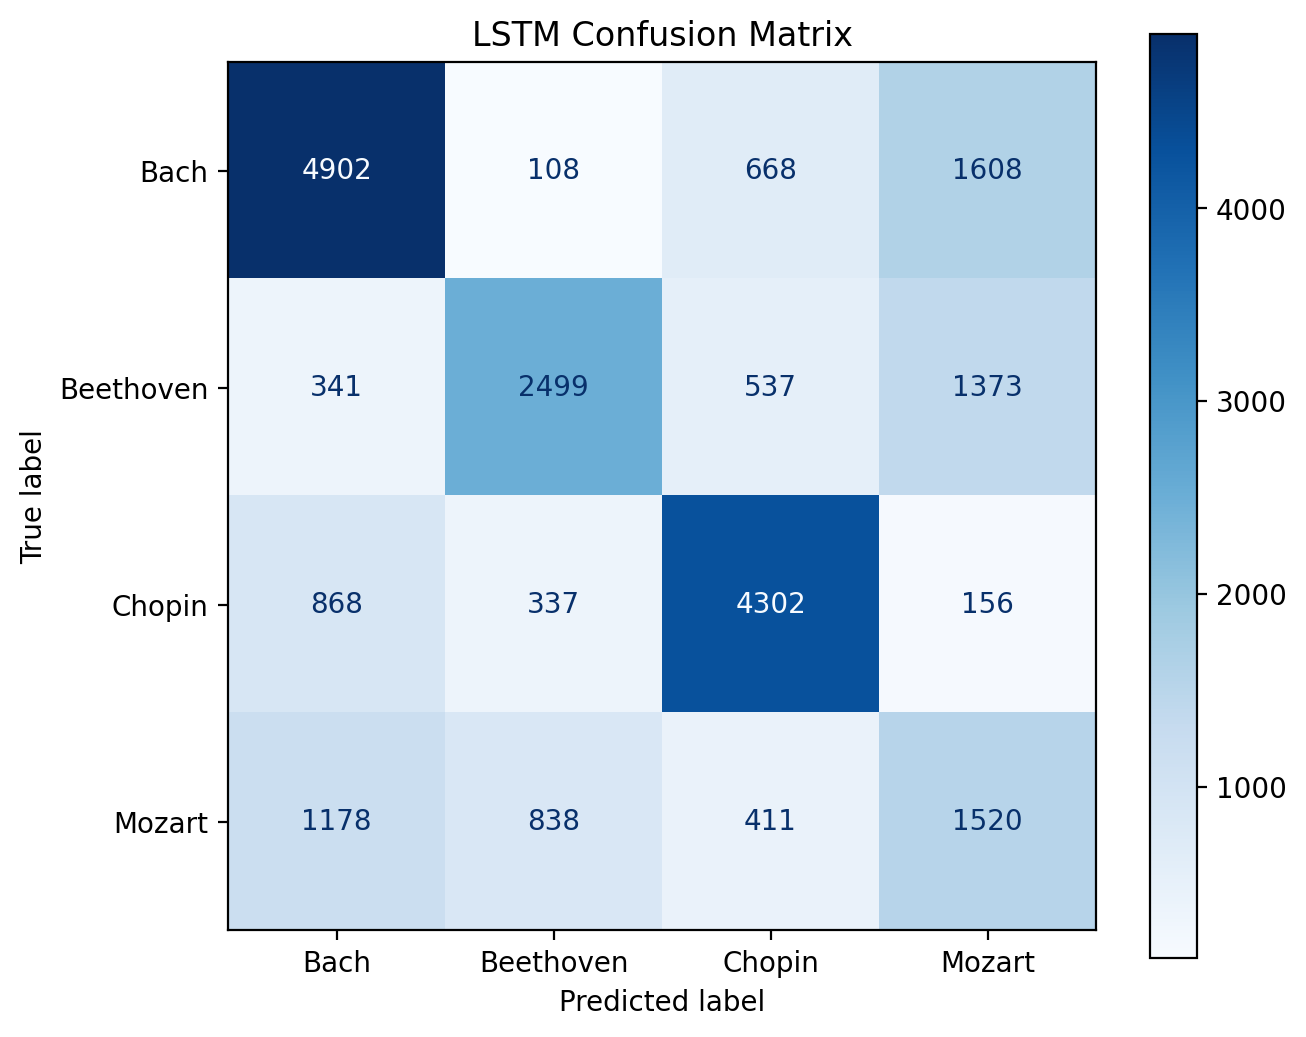

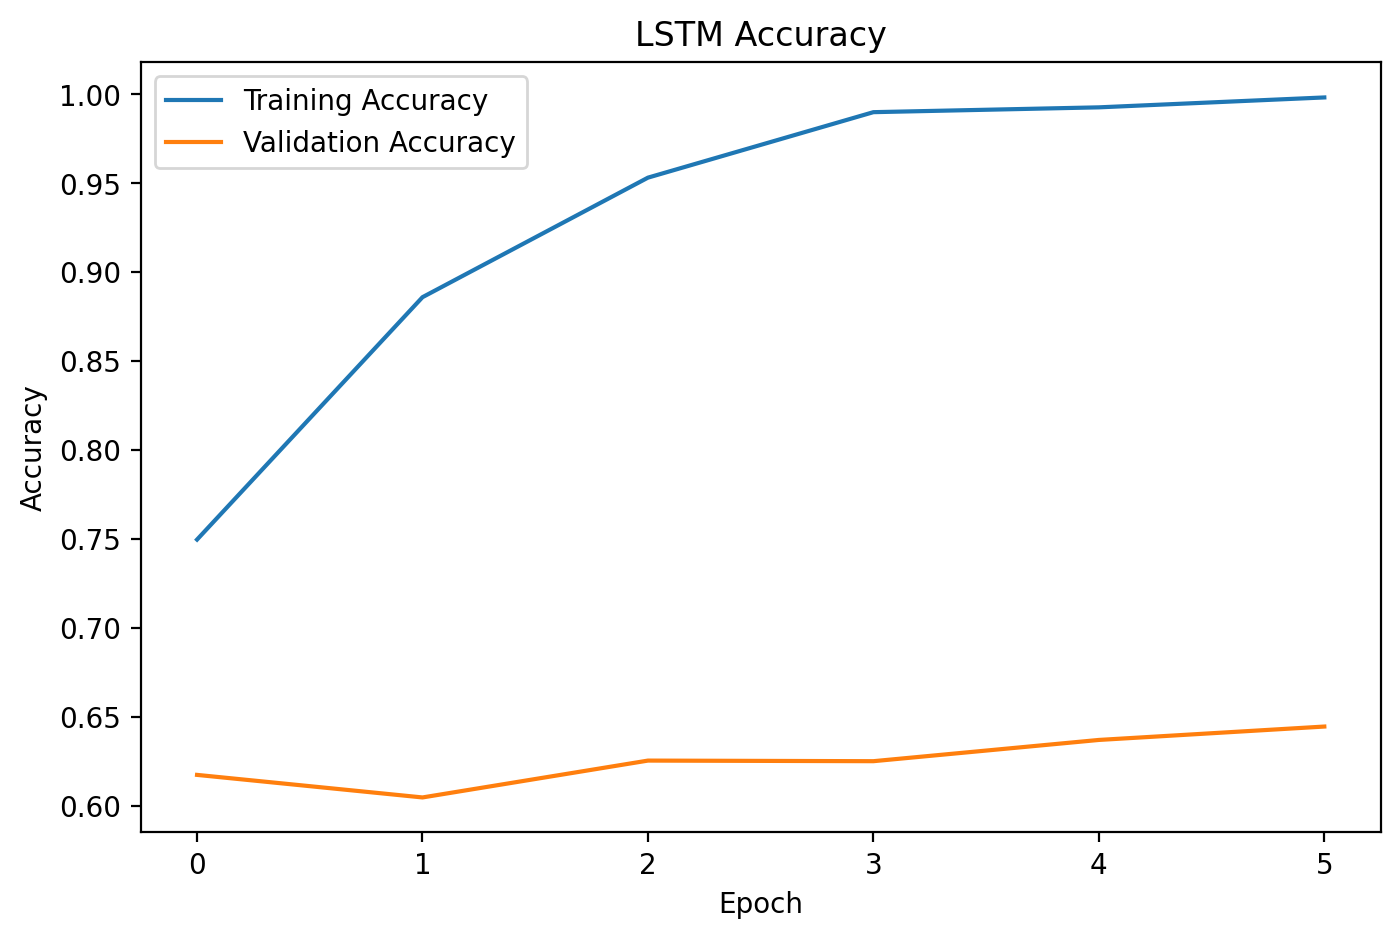

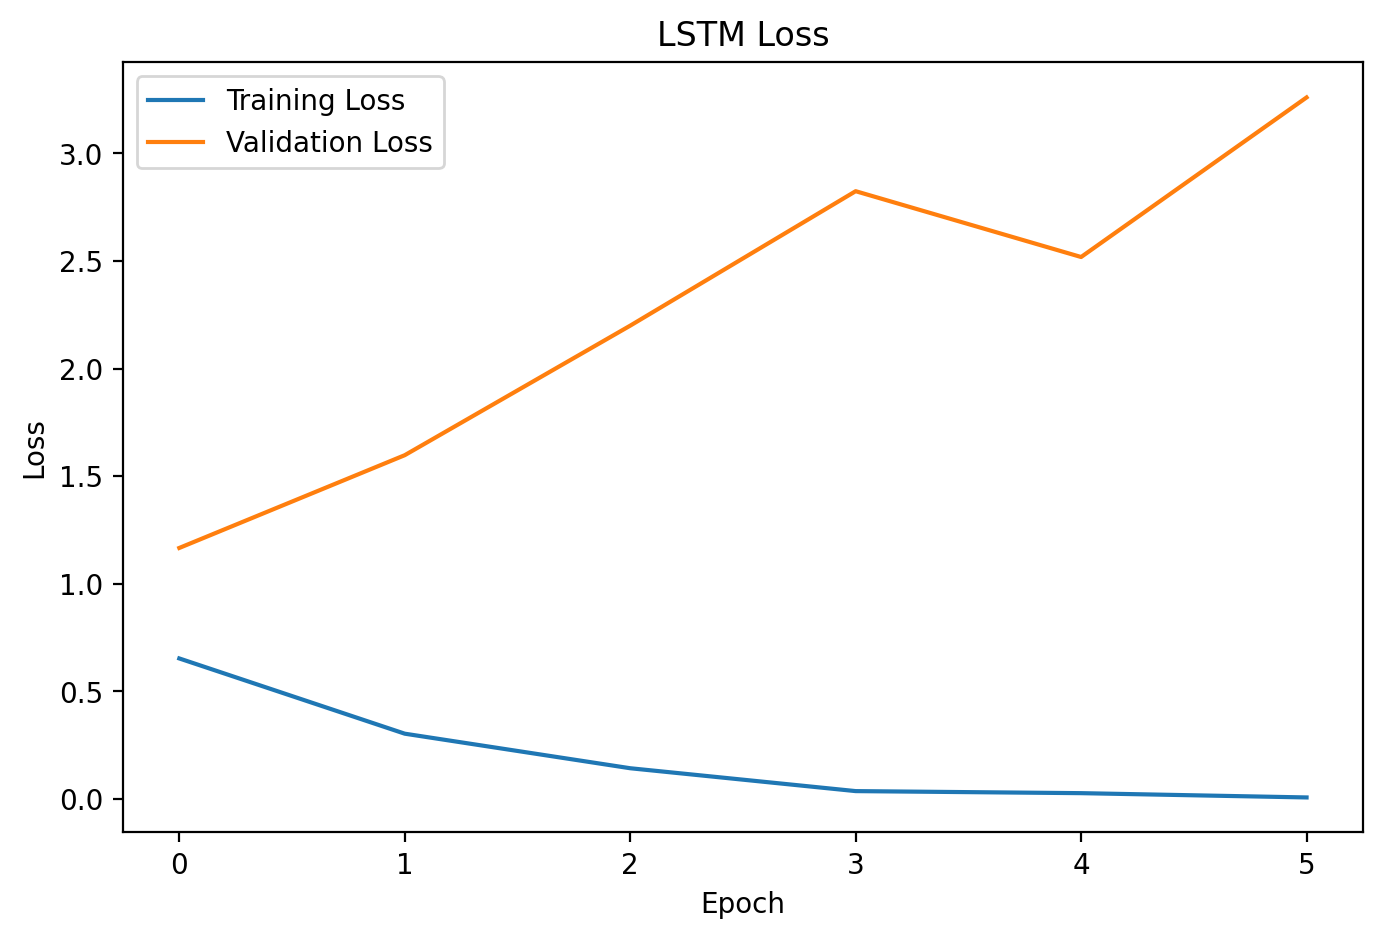

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step

Single Prediction Example
Predicted Composer : Beethoven
Confidence : 96.89%


In [54]:
# ==========================================================
# LSTM MODEL EVALUATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Load Best Saved LSTM Model
# ----------------------------------------------------------

lstm_model = load_model("best_lstm.keras")

# ----------------------------------------------------------
# Evaluate on Test Data
# ----------------------------------------------------------
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

print("y_train:", y_train.shape)
print("y_val:", y_val.shape)
print("y_test:", y_test.shape)

print("Total test samples:", len(y_test))
test_loss, test_accuracy = lstm_model.evaluate(X_test, y_test, verbose=1)

print("="*60)
print("LSTM TEST RESULTS")
print("="*60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

y_pred_prob = lstm_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

# ----------------------------------------------------------
# Performance Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("LSTM Confusion Matrix")
plt.show()

# ----------------------------------------------------------
# Training History
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("LSTM Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("LSTM Loss")

plt.legend()

plt.show()

# ----------------------------------------------------------
# Predicting One Sample
# ----------------------------------------------------------

sample = X_test[0].reshape(1, -1)

prediction = lstm_model.predict(sample)

predicted_class = np.argmax(prediction)

composer = label_encoder.inverse_transform([predicted_class])[0]

confidence = np.max(prediction)

print("\nSingle Prediction Example")

print("Predicted Composer :", composer)

print(f"Confidence : {confidence*100:.2f}%")

# Building CNN Model

Develop a one-dimensional Convolutional Neural Network for music genre classification.

In [55]:
# ==========================================================
# BUILD CNN MODEL
# ==========================================================

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Input,
    Embedding,
    Conv1D,
    BatchNormalization,
    MaxPooling1D,
    GlobalMaxPooling1D,
    Dense,
    Dropout
)
from tensorflow.keras.optimizers import Adam

vocab_size = len(note_to_int)

cnn_model = Sequential([

    Input(shape=(100,)),

    Embedding(
        input_dim=vocab_size,
        output_dim=128
    ),

    Conv1D(
        filters=128,
        kernel_size=5,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    Conv1D(
        filters=64,
        kernel_size=3,
        activation="relu",
        padding="same"
    ),

    BatchNormalization(),

    MaxPooling1D(pool_size=2),

    GlobalMaxPooling1D(),

    Dense(128, activation="relu"),

    Dropout(0.4),

    Dense(64, activation="relu"),

    Dropout(0.3),

    Dense(4, activation="softmax")

])

cnn_model.compile(

    optimizer=Adam(learning_rate=0.0003),

    loss="sparse_categorical_crossentropy",

    metrics=["accuracy"]

)

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │        87,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211,588 (826.52 KB)

 Trainable params: 211,204 (825.02 KB)

 Non-trainable params: 384 (1.50 KB)

## CNN Model Training

Define the CNN architecture, train the model, and evaluate its performance.

In [56]:
from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,                   # model training
    ModelCheckpoint
)

early_stop = EarlyStopping(

    monitor="val_loss",

    patience=8,

    restore_best_weights=True

)

reduce_lr = ReduceLROnPlateau(

    monitor="val_loss",

    factor=0.5,

    patience=3,

    min_lr=1e-6,

    verbose=1

)

checkpoint = ModelCheckpoint(

    "best_cnn.keras",

    monitor="val_accuracy",

    save_best_only=True

)

history = cnn_model.fit(

    X_train,

    y_train,

    validation_data=(X_val, y_val),

    epochs=50,

    batch_size=16,

    callbacks=[

        early_stop,

        reduce_lr,

        checkpoint

    ],

    shuffle=True,

    verbose=1

)

Epoch 1/50
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 27s 4ms/step - accuracy: 0.9292 - loss: 0.1890 - val_accuracy: 0.5553 - val_loss: 2.6431 - learning_rate: 3.0000e-04
Epoch 2/50
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9917 - loss: 0.0260 - val_accuracy: 0.6326 - val_loss: 2.2538 - learning_rate: 3.0000e-04
Epoch 3/50
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9943 - loss: 0.0186 - val_accuracy: 0.5947 - val_loss: 3.1711 - learning_rate: 3.0000e-04
Epoch 4/50
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9962 - loss: 0.0131 - val_accuracy: 0.6183 - val_loss: 3.2490 - learning_rate: 3.0000e-04
Epoch 5/50
4252/4265 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9962 - loss: 0.0120
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/step - accuracy: 0.9963 - loss: 0.0122 - val_accuracy: 0.6458 - val_loss: 3.1169 - learning_rate: 3.0000e-04
Epoch 6/50
4265/4265 ━━━━━━━━━━━━━━━━━━━━ 12s 3ms/st

In [57]:
# ==========================================================
# Model Testing
# ==========================================================

from tensorflow.keras.models import load_model

cnn_model = load_model("best_cnn.keras")

test_loss, test_accuracy = cnn_model.evaluate(

    X_test,

    y_test,

    verbose=1

)

print("="*60)
print("CNN TEST RESULTS")
print("="*60)

print("Test Loss     :", round(test_loss,4))
print("Test Accuracy :", round(test_accuracy,4))

677/677 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.6152 - loss: 2.7604
CNN TEST RESULTS
Test Loss     : 2.7604
Test Accuracy : 0.6152


677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6152 - loss: 2.7604
CNN TEST RESULTS
Test Loss      : 2.7604
Test Accuracy  : 0.6152
677/677 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step

Classification Report

              precision    recall  f1-score   support

        Bach       0.62      0.81      0.70      7286
   Beethoven       0.53      0.60      0.56      4750
      Chopin       0.79      0.59      0.68      5663
      Mozart       0.49      0.32      0.38      3947

    accuracy                           0.62     21646
   macro avg       0.61      0.58      0.58     21646
weighted avg       0.62      0.62      0.61     21646

Accuracy : 0.6152
Precision: 0.6214
Recall   : 0.6152
F1 Score : 0.6065


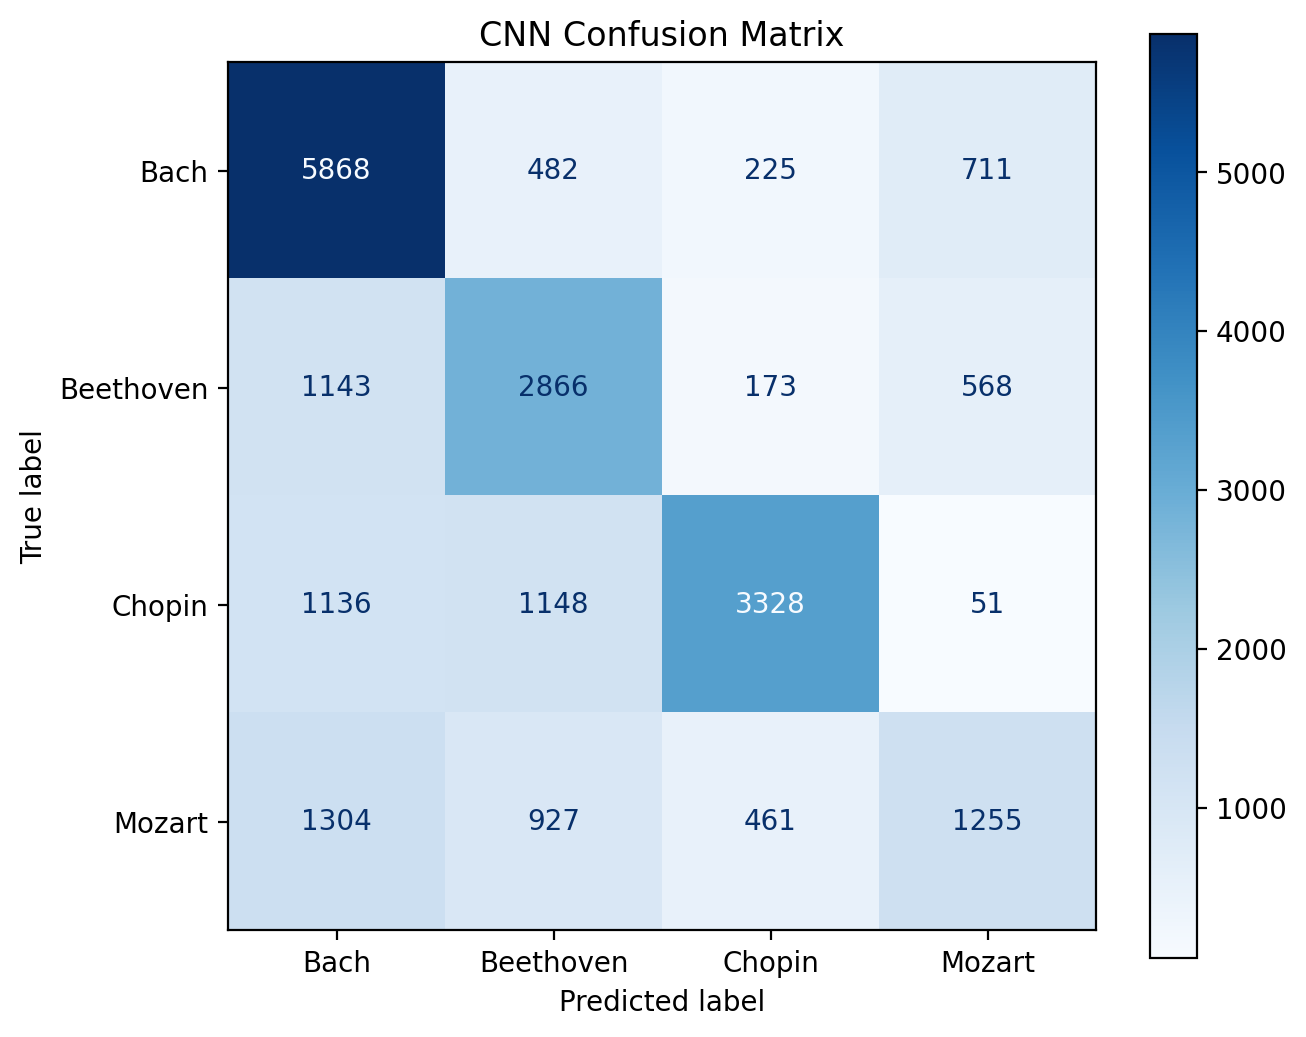

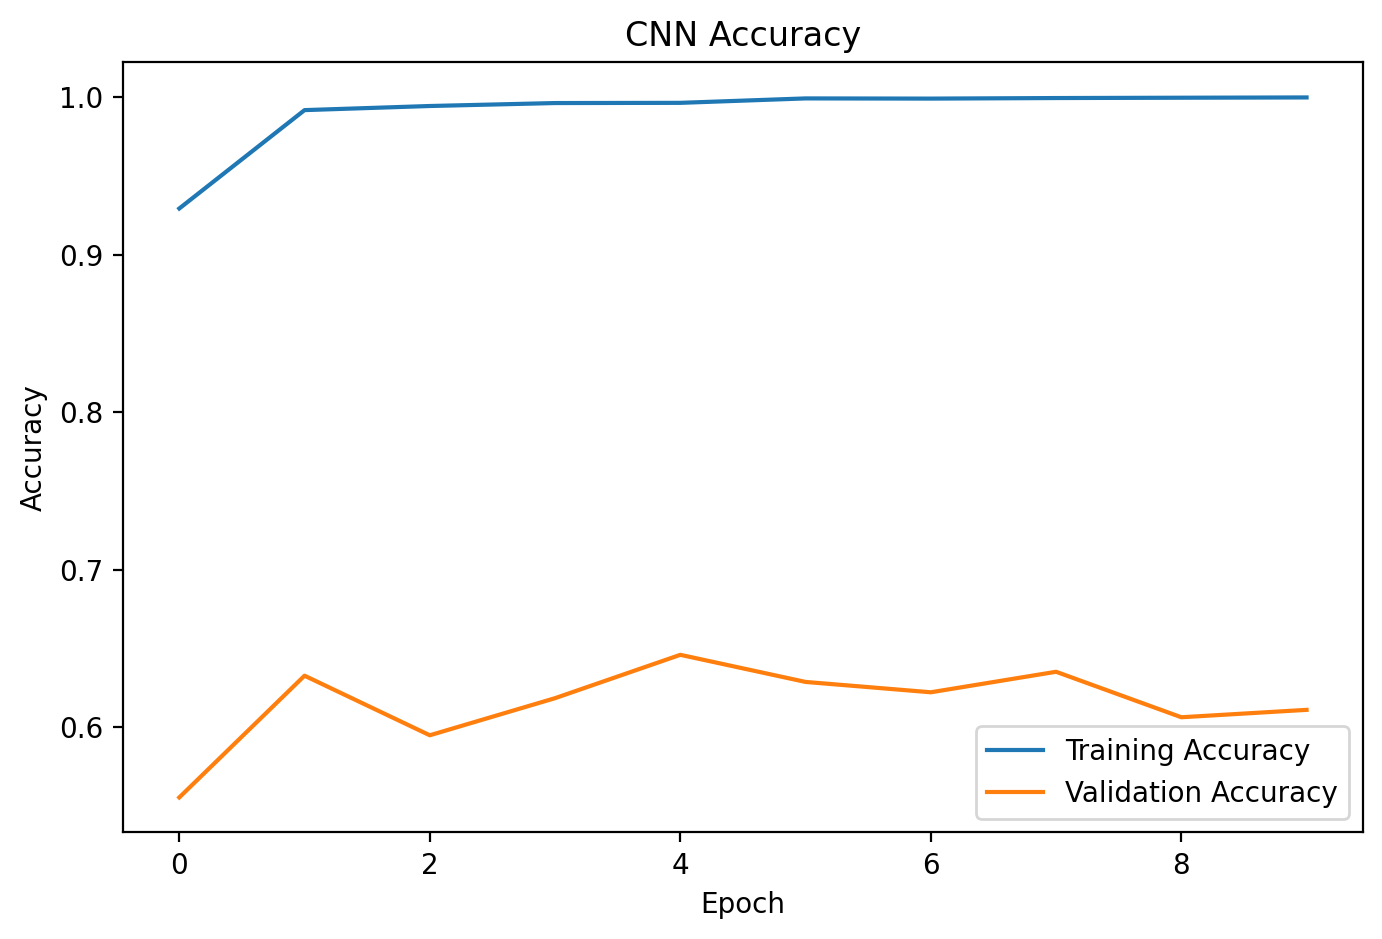

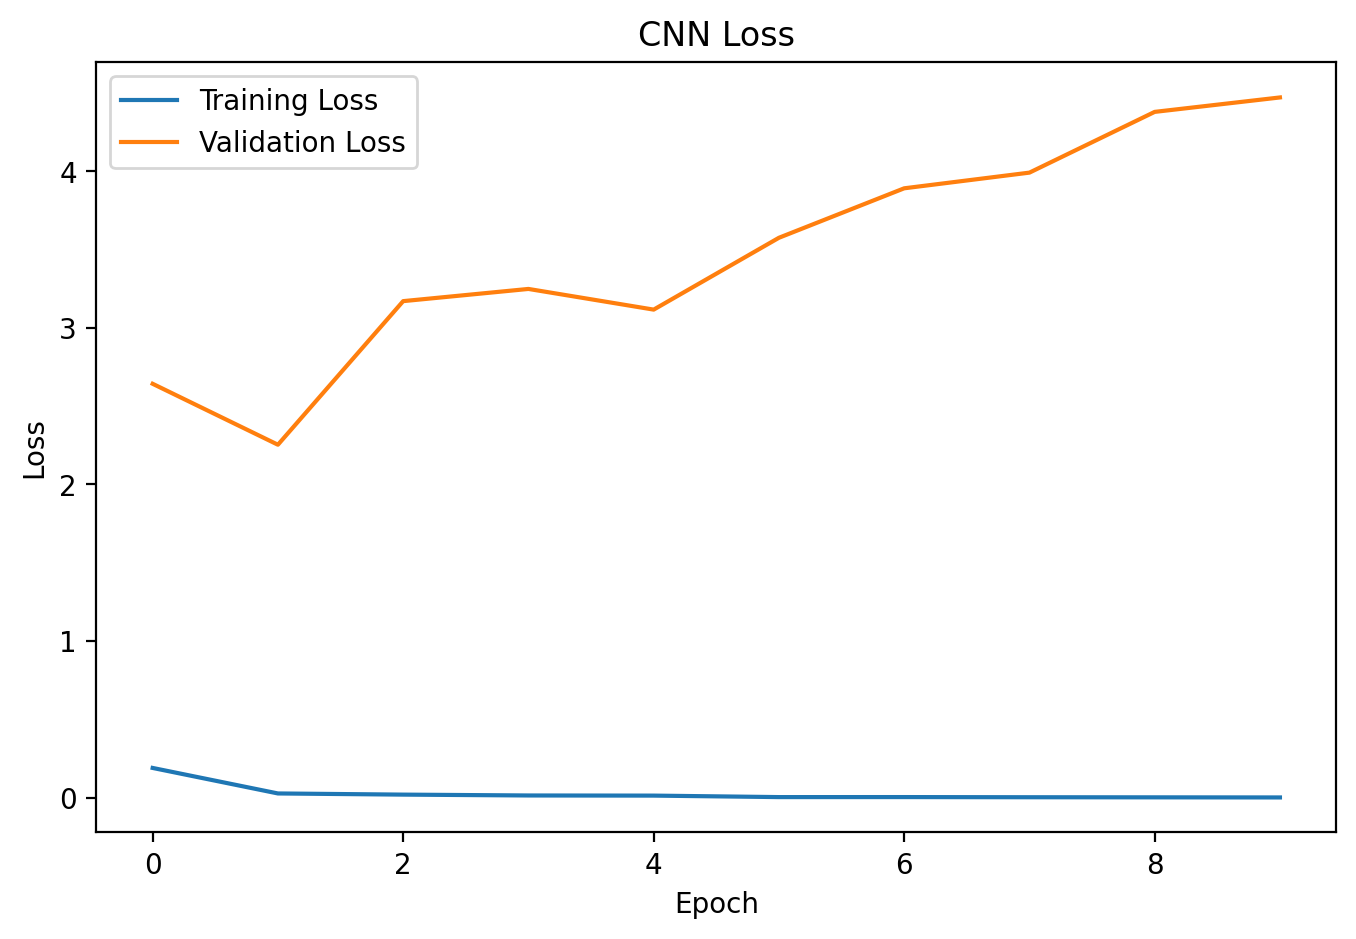

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 534ms/step

Single Prediction Example
Predicted Composer : Beethoven
Confidence : 100.00%


In [58]:
# ==========================================================
# CNN MODEL EVALUATION
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# ----------------------------------------------------------
# Load Best Saved CNN Model
# ----------------------------------------------------------

cnn_model = load_model("best_cnn.keras")

# ----------------------------------------------------------
# Evaluate on Test Data
# ----------------------------------------------------------

test_loss, test_accuracy = cnn_model.evaluate(X_test, y_test, verbose=1)

print("="*60)
print("CNN TEST RESULTS")
print("="*60)

print(f"Test Loss      : {test_loss:.4f}")
print(f"Test Accuracy  : {test_accuracy:.4f}")

# ----------------------------------------------------------
# Predictions
# ----------------------------------------------------------

y_pred_prob = cnn_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)

# ----------------------------------------------------------
# Performance Metrics
# ----------------------------------------------------------

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("\nClassification Report\n")

print(classification_report(
    y_test,
    y_pred,
    target_names=label_encoder.classes_
))

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")

# ----------------------------------------------------------
# Confusion Matrix
# ----------------------------------------------------------

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_encoder.classes_
)

fig, ax = plt.subplots(figsize=(7,6))

disp.plot(
    cmap="Blues",
    values_format="d",
    ax=ax
)

plt.title("CNN Confusion Matrix")
plt.show()

# ----------------------------------------------------------
# Training History
# ----------------------------------------------------------

plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")

plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("CNN Accuracy")

plt.legend()

plt.show()


plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")

plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("CNN Loss")

plt.legend()

plt.show()

# ----------------------------------------------------------
# Predict One Sample
# ----------------------------------------------------------

sample = X_test[0].reshape(1, -1)

prediction = cnn_model.predict(sample)

predicted_class = np.argmax(prediction)

composer = label_encoder.inverse_transform([predicted_class])[0]

confidence = np.max(prediction)

print("\nSingle Prediction Example")

print("Predicted Composer :", composer)

print(f"Confidence : {confidence*100:.2f}%")

# SHAP Explainability

Use SHAP to interpret the CNN model and identify which input features contribute most to classification decisions.

In [59]:
!pip install shap

In [60]:
import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

In [61]:
cnn_model = load_model("best_cnn.keras")

cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 128)       │        87,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 100, 128)       │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 100, 128)       │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 50, 64)         │        24,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 50, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 25, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 633,998 (2.42 MB)

 Trainable params: 211,204 (825.02 KB)

 Non-trainable params: 384 (1.50 KB)

 Optimizer params: 422,410 (1.61 MB)

In [62]:
background = X_train[:100]

test_samples = X_test[:20]

print("Background Shape :", background.shape)
print("Test Shape :", test_samples.shape)

Background Shape : (100, 100)
Test Shape : (20, 100)


## Model Interpretation

Install SHAP, load the trained model, compute SHAP values, and visualize feature importance.

Background Shape : (100, 100)
Test Shape : (20, 100)

Using GradientExplainer...

GradientExplainer failed.
zero-dimensional arrays cannot be concatenated

Switching to KernelExplainer...

2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 2s/step


  0%|          | 0/20 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
157/157 ━━━━━

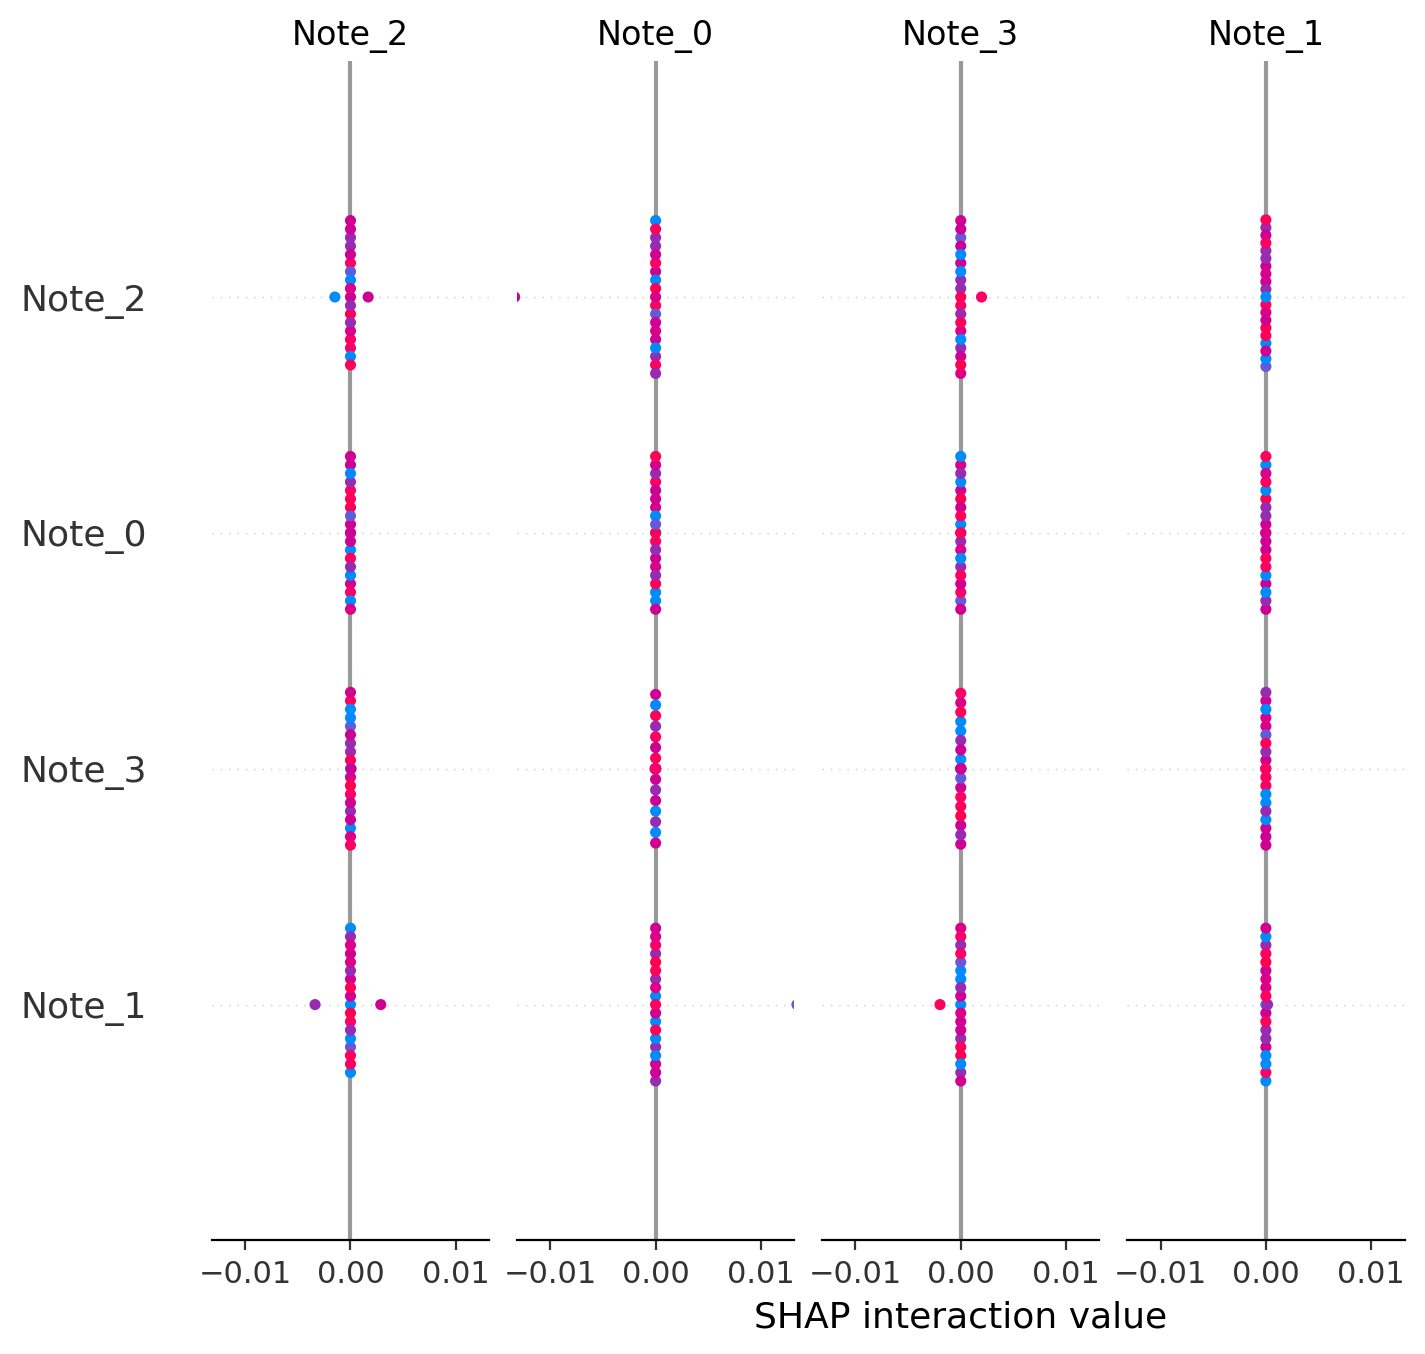


Generating SHAP Feature Importance Plot...


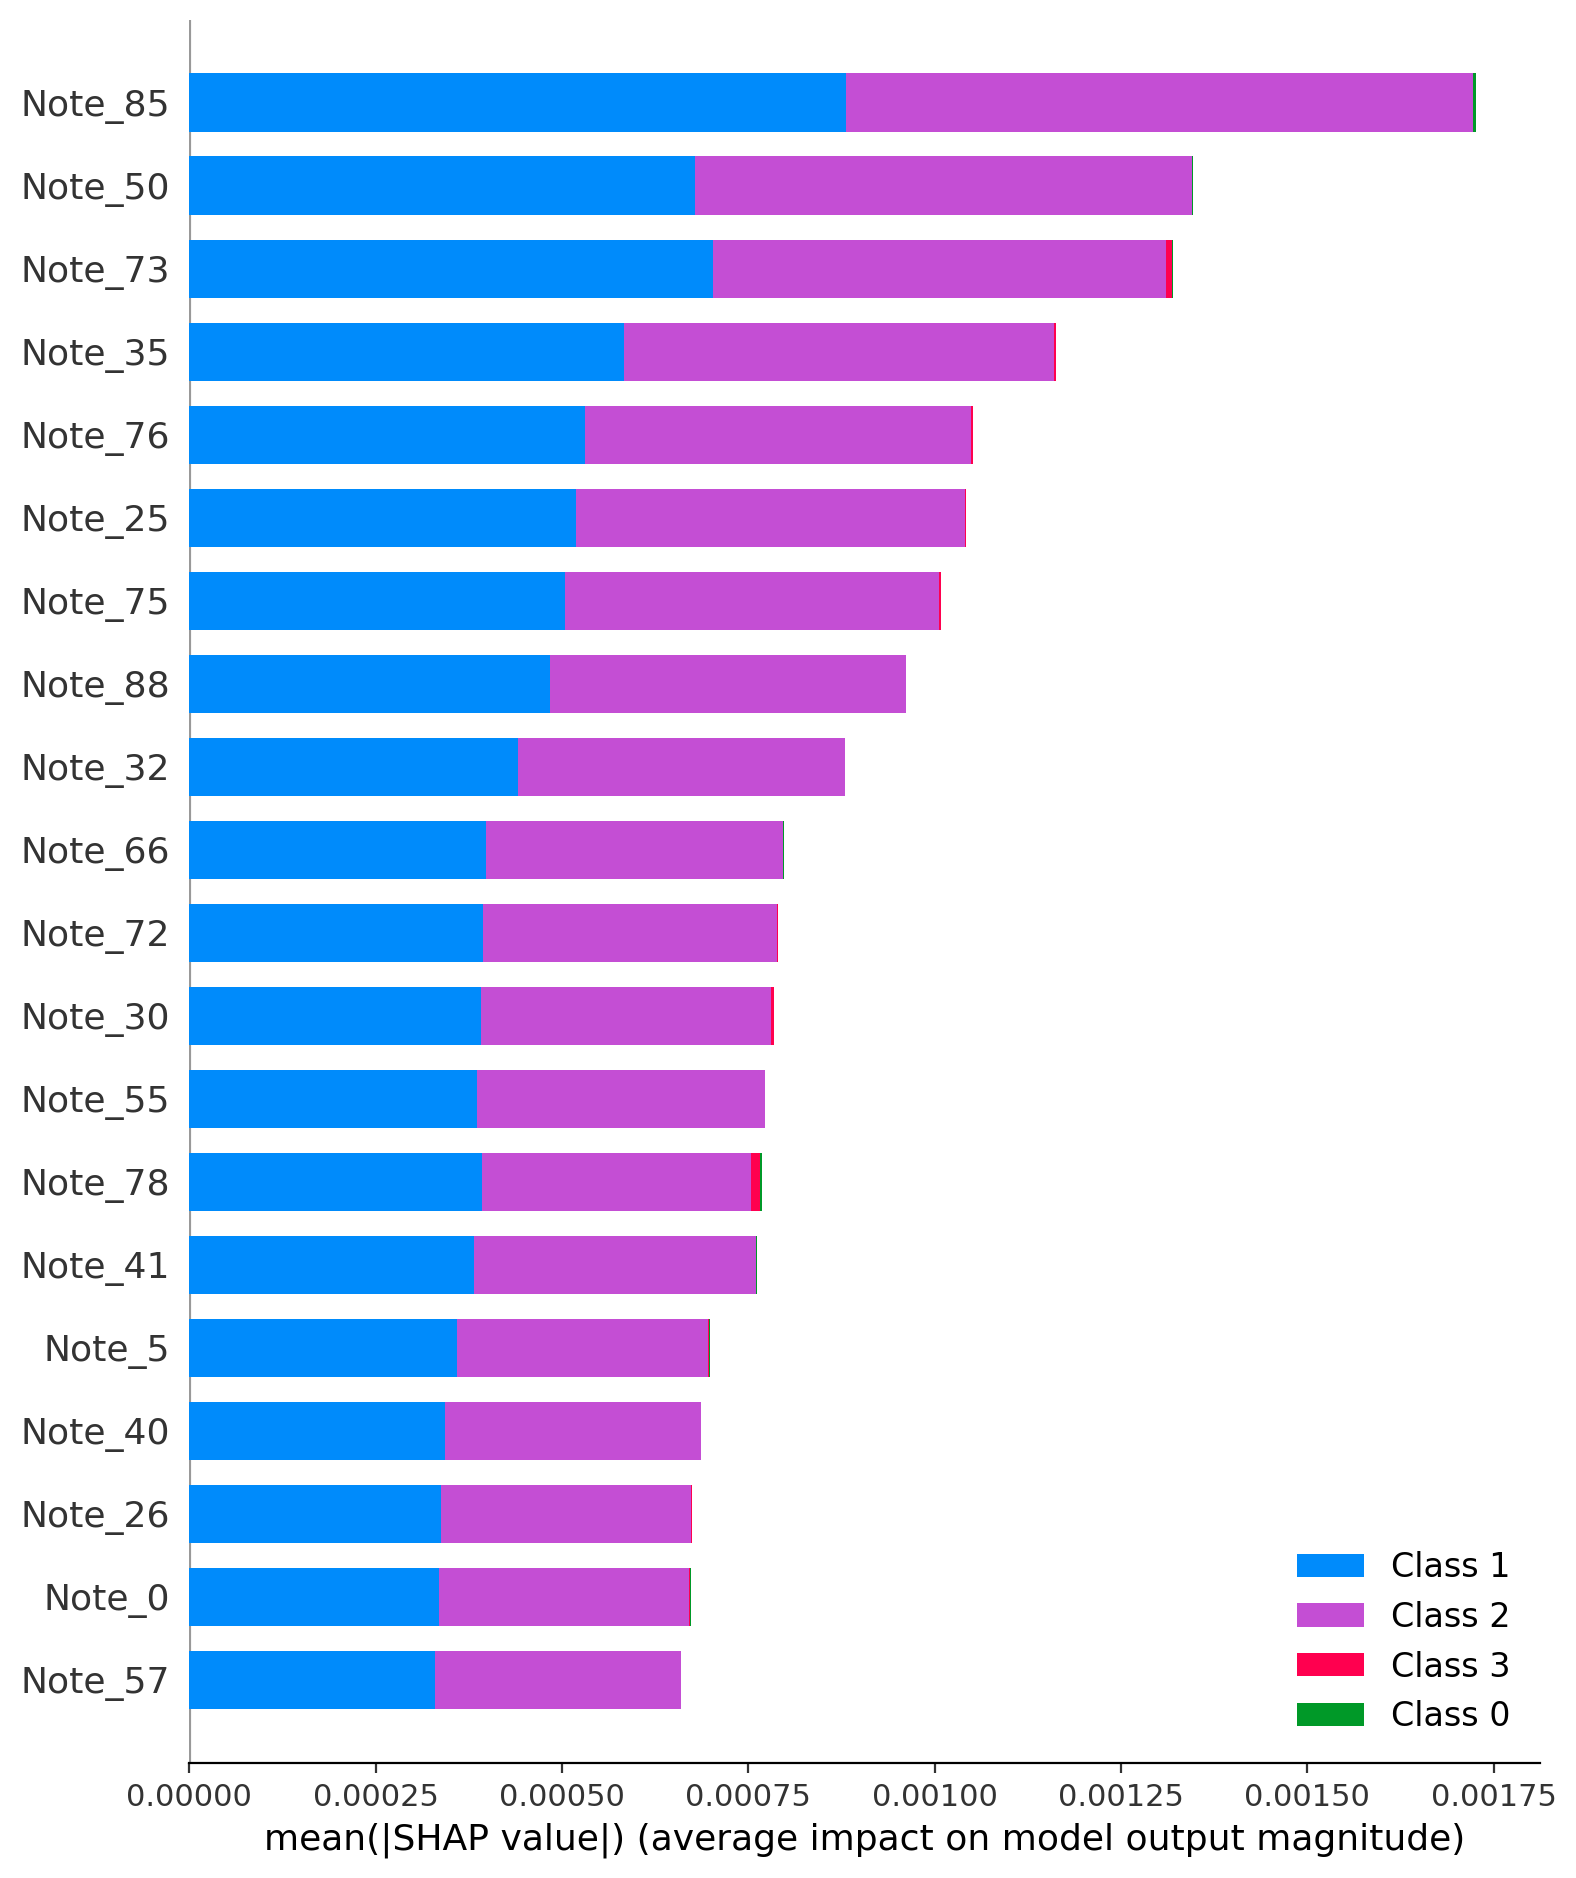


SHAP Explainability Completed Successfully!


In [63]:
# ==========================================================
# SHAP EXPLAINABILITY FOR CNN MODEL
# ==========================================================

import shap
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model

# ----------------------------------------------------------
# Load Best CNN Model
# ----------------------------------------------------------

cnn_model = load_model("best_cnn.keras")

# ----------------------------------------------------------
# Background and Test Samples
# ----------------------------------------------------------

background = X_train[:100]
test_samples = X_test[:20]

print("Background Shape :", background.shape)
print("Test Shape :", test_samples.shape)

# ----------------------------------------------------------
# Create SHAP Explainer
# ----------------------------------------------------------

try:

    print("\nUsing GradientExplainer...\n")

    explainer = shap.GradientExplainer(
        cnn_model,
        background
    )

    shap_values = explainer.shap_values(test_samples)

except Exception as e:

    print("GradientExplainer failed.")
    print(e)

    print("\nSwitching to KernelExplainer...\n")

    explainer = shap.KernelExplainer(
        cnn_model.predict,
        background[:50]
    )

    shap_values = explainer.shap_values(
        test_samples,
        nsamples=100
    )

print("\nSHAP values computed successfully!")

# ----------------------------------------------------------
# Prediction for First Sample
# ----------------------------------------------------------

prediction = cnn_model.predict(test_samples)

predicted_class = np.argmax(prediction[0])

predicted_composer = label_encoder.inverse_transform(
    [predicted_class]
)[0]

confidence = np.max(prediction[0])

print("\nPredicted Composer :", predicted_composer)
print(f"Prediction Confidence : {confidence*100:.2f}%")

# ----------------------------------------------------------
# Summary Plot
# ----------------------------------------------------------

print("\nGenerating SHAP Summary Plot...")

try:

    shap.summary_plot(

        shap_values,

        test_samples,

        feature_names=[f"Note_{i}" for i in range(test_samples.shape[1])]

    )

except:

    shap.summary_plot(

        shap_values[0],

        test_samples,

        feature_names=[f"Note_{i}" for i in range(test_samples.shape[1])]

    )

# ----------------------------------------------------------
# Feature Importance Plot
# ----------------------------------------------------------

print("\nGenerating SHAP Feature Importance Plot...")

try:

    shap.summary_plot(

        shap_values,

        test_samples,

        plot_type="bar",

        feature_names=[f"Note_{i}" for i in range(test_samples.shape[1])]

    )

except:

    shap.summary_plot(

        shap_values[0],

        test_samples,

        plot_type="bar",

        feature_names=[f"Note_{i}" for i in range(test_samples.shape[1])]

    )

print("\nSHAP Explainability Completed Successfully!")

## Tuning


In [64]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 11.1 MB/s eta 0:00:00


## Automated Hyperparameter Optimization

Configure the tuner, perform the hyperparameter search, retrieve the best model configuration, and build the optimized CNN architecture.

In [65]:
import keras_tuner as kt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam

vocab_size = len(note_to_int)

def build_lstm_model(hp):

    model = Sequential()

    model.add(Input(shape=(100,)))

    model.add(
        Embedding(
            input_dim=vocab_size,
            output_dim=hp.Choice(
                "embedding_dim",
                [64,128,256]
            )
        )
    )

    model.add(
        LSTM(
            units=hp.Choice(
                "lstm1_units",
                [64,128,256]
            ),
            return_sequences=True
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout1",
                0.2,
                0.5,
                step=0.1
            )
        )
    )

    model.add(
        LSTM(
            hp.Choice(
                "lstm2_units",
                [32,64,128]
            )
        )
    )

    model.add(
        Dropout(
            hp.Float(
                "dropout2",
                0.2,
                0.5,
                step=0.1
            )
        )
    )

    model.add(
        Dense(
            hp.Choice(
                "dense_units",
                [32,64,128]
            ),
            activation="relu"
        )
    )

    model.add(Dense(4, activation="softmax"))

    model.compile(

        optimizer=Adam(

            learning_rate=hp.Choice(
                "learning_rate",
                [1e-2,1e-3,5e-4,1e-4]
            )

        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

In [66]:
tuner = kt.Hyperband(

    build_lstm_model,

    objective="val_accuracy",

    max_epochs=20,

    factor=3,

    directory="tuning",

    project_name="lstm_music"

)

tuner.search_space_summary()

Search space summary
Default search space size: 7
embedding_dim (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
lstm1_units (Choice)
{'default': 64, 'conditions': [], 'values': [64, 128, 256], 'ordered': True}
dropout1 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
lstm2_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
dropout2 (Float)
{'default': 0.2, 'conditions': [], 'min_value': 0.2, 'max_value': 0.5, 'step': 0.1, 'sampling': 'linear'}
dense_units (Choice)
{'default': 32, 'conditions': [], 'values': [32, 64, 128], 'ordered': True}
learning_rate (Choice)
{'default': 0.01, 'conditions': [], 'values': [0.01, 0.001, 0.0005, 0.0001], 'ordered': True}


In [67]:
early_stop = tf.keras.callbacks.EarlyStopping(

    monitor="val_loss",

    patience=5,

    restore_best_weights=True

)

tuner.search(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=20,

    batch_size=32,

    callbacks=[early_stop]

)

Trial 30 Complete [00h 03m 12s]
val_accuracy: 0.6113848686218262

Best val_accuracy So Far: 0.6686491370201111
Total elapsed time: 01h 10m 45s


In [68]:
best_hp = tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

{'embedding_dim': 256, 'lstm1_units': 128, 'dropout1': 0.2, 'lstm2_units': 64, 'dropout2': 0.2, 'dense_units': 128, 'learning_rate': 0.001, 'tuner/epochs': 20, 'tuner/initial_epoch': 7, 'tuner/bracket': 2, 'tuner/round': 2, 'tuner/trial_id': '0012'}


In [69]:
best_model = tuner.hypermodel.build(best_hp)

history = best_model.fit(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=50,

    batch_size=32,

    callbacks=[

        tf.keras.callbacks.EarlyStopping(

            monitor="val_loss",

            patience=8,

            restore_best_weights=True

        ),

        tf.keras.callbacks.ReduceLROnPlateau(

            monitor="val_loss",

            factor=0.5,

            patience=3

        )

    ]

)

best_model.save("best_lstm_tuned.keras")

Epoch 1/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - accuracy: 0.7738 - loss: 0.6123 - val_accuracy: 0.5760 - val_loss: 1.4264 - learning_rate: 0.0010
Epoch 2/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9227 - loss: 0.2071 - val_accuracy: 0.6229 - val_loss: 2.1428 - learning_rate: 0.0010
Epoch 3/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9869 - loss: 0.0443 - val_accuracy: 0.6245 - val_loss: 2.3968 - learning_rate: 0.0010
Epoch 4/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9948 - loss: 0.0189 - val_accuracy: 0.6305 - val_loss: 3.0783 - learning_rate: 0.0010
Epoch 5/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9989 - loss: 0.0044 - val_accuracy: 0.6403 - val_loss: 3.2978 - learning_rate: 5.0000e-04
Epoch 6/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.6286 - val_loss: 3.3555 - learning_rate: 5.0000e-04
Epoch 7/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 27s 13ms/step 

In [70]:
def build_cnn_model(hp):

    model = Sequential()

    model.add(Input(shape=(100,)))

    model.add(

        Embedding(

            input_dim=vocab_size,

            output_dim=hp.Choice(

                "embedding",

                [64,128,256]

            )

        )

    )

    model.add(

        Conv1D(

            filters=hp.Choice(

                "filters1",

                [64,128,256]

            ),

            kernel_size=hp.Choice(

                "kernel1",

                [3,5,7]

            ),

            activation="relu",

            padding="same"

        )

    )

    model.add(MaxPooling1D())

    model.add(

        Conv1D(

            filters=hp.Choice(

                "filters2",

                [32,64,128]

            ),

            kernel_size=3,

            activation="relu"

        )

    )

    model.add(GlobalMaxPooling1D())

    model.add(

        Dropout(

            hp.Float(

                "dropout",

                0.2,

                0.5,

                step=0.1

            )

        )

    )

    model.add(

        Dense(

            hp.Choice(

                "dense",

                [32,64,128]

            ),

            activation="relu"

        )

    )

    model.add(Dense(4,activation="softmax"))

    model.compile(

        optimizer=Adam(

            learning_rate=hp.Choice(

                "lr",

                [1e-2,1e-3,5e-4,1e-4]

            )

        ),

        loss="sparse_categorical_crossentropy",

        metrics=["accuracy"]

    )

    return model

In [71]:
cnn_tuner = kt.Hyperband(

    build_cnn_model,

    objective="val_accuracy",

    max_epochs=20,

    directory="tuning",

    project_name="cnn_music"

)

cnn_tuner.search(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=20,

    callbacks=[

        tf.keras.callbacks.EarlyStopping(

            patience=5,

            restore_best_weights=True

        )

    ]

)

best_hp = cnn_tuner.get_best_hyperparameters(1)[0]

print(best_hp.values)

best_cnn = cnn_tuner.hypermodel.build(best_hp)

history = best_cnn.fit(

    X_train,

    y_train,

    validation_data=(X_val,y_val),

    epochs=50,

    batch_size=32,

    callbacks=[

        tf.keras.callbacks.EarlyStopping(

            patience=8,

            restore_best_weights=True

        ),

        tf.keras.callbacks.ReduceLROnPlateau(

            factor=0.5,

            patience=3

        )

    ]

)

best_cnn.save("best_cnn_tuned.keras")

Trial 30 Complete [00h 00m 43s]
val_accuracy: 0.630869448184967

Best val_accuracy So Far: 0.685188353061676
Total elapsed time: 00h 18m 12s
{'embedding': 256, 'filters1': 64, 'kernel1': 7, 'filters2': 128, 'dropout': 0.30000000000000004, 'dense': 64, 'lr': 0.001, 'tuner/epochs': 3, 'tuner/initial_epoch': 0, 'tuner/bracket': 2, 'tuner/round': 0}
Epoch 1/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9569 - loss: 0.1102 - val_accuracy: 0.5707 - val_loss: 3.0997 - learning_rate: 0.0010
Epoch 2/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9960 - loss: 0.0126 - val_accuracy: 0.6181 - val_loss: 4.4243 - learning_rate: 0.0010
Epoch 3/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9971 - loss: 0.0092 - val_accuracy: 0.6037 - val_loss: 5.2649 - learning_rate: 0.0010
Epoch 4/50
2133/2133 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9974 - loss: 0.0090 - val_accuracy: 0.5970 - val_loss: 5.9417 - learning_rate: 0.0010
Epoch 5/50
2133/2133 ━━━━━━━━━━━━━━